In [3]:
# Đọc dữ liệu
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("mental_health.csv")
data.columns = data.columns.str.strip().str.lower()
data = data[data["gender"].isin(["Male", "Female"])].reset_index(drop=True)
data["employee_id"] = range(1, len(data) + 1)
sns.set_theme(style="whitegrid")
print(f"Kích thước dữ liệu: {data.shape}")
print(data["gender"].value_counts())
data.head()

Kích thước dữ liệu: (95002, 22)
gender
Male      65243
Female    29759
Name: count, dtype: int64


,employee_id,age,gender,job_role,seniority_level,years_experience,work_mode,salary_usd,work_hours_per_week,sleep_hours_per_night,...,deadline_pressure_score,stress_score,burnout_score,phq9_score,phq9_category,gad7_score,gad7_category,burnout_level,seeks_mental_health_support,job_change_intention
0,1,33,Male,Software Engineer,Lead,11,Remote,40000,55,6.3,...,8.3,10.0,10.0,19,Moderately Severe (15-19),12,Moderate (10-14),Severe,1,1
1,2,22,Female,Data Analyst,Principal,0,Remote,57714,50,6.8,...,2.6,7.1,7.4,9,Mild (5-9),7,Mild (5-9),Severe,0,1
2,3,32,Male,Data Analyst,Junior,10,Hybrid,42823,41,3.6,...,4.3,6.7,3.8,2,None (0-4),5,Mild (5-9),Moderate,0,1
3,4,29,Female,DevOps Engineer,Mid,8,Hybrid,77421,39,6.7,...,10.0,7.6,3.9,6,Mild (5-9),8,Mild (5-9),Moderate,0,0
4,5,31,Male,Software Engineer,Mid,9,Hybrid,98067,45,6.9,...,5.4,3.2,2.2,0,None (0-4),0,Minimal (0-4),Low,0,0


In [4]:
# EDA 1: Kích thước và kiểu dữ liệu
print("Kích thước dữ liệu và kiểu dữ liệu")
print(data.shape)
print(data.dtypes)

Kích thước dữ liệu và kiểu dữ liệu
(95002, 22)
employee_id                      int64
age                              int64
gender                          object
job_role                        object
seniority_level                 object
years_experience                 int64
work_mode                       object
salary_usd                       int64
work_hours_per_week              int64
sleep_hours_per_night          float64
uses_therapy                     int64
ai_tools_daily                   int64
deadline_pressure_score        float64
stress_score                   float64
burnout_score                  float64
phq9_score                       int64
phq9_category                   object
gad7_score                       int64
gad7_category                   object
burnout_level                   object
seeks_mental_health_support      int64
job_change_intention             int64
dtype: object


In [5]:
# EDA 2: Thống kê mô tả
data.describe()

,employee_id,age,years_experience,salary_usd,work_hours_per_week,sleep_hours_per_night,uses_therapy,ai_tools_daily,deadline_pressure_score,stress_score,burnout_score,phq9_score,gad7_score,seeks_mental_health_support,job_change_intention
count,95002.000000,95002.000000,95002.000000,95002.000000,95002.000000,95002.000000,95002.000000,95002.000000,95002.000000,95002.000000,95002.000000,95002.000000,95002.000000,95002.000000,95002.000000
mean,47501.500000,31.308930,9.345793,83321.248563,47.101587,6.102559,0.151544,0.730079,6.384892,7.055336,5.397274,6.269973,5.117692,0.496095,0.320267
std,27424.859474,6.428277,6.401533,39415.824186,5.244645,0.999199,0.358580,0.443921,1.768218,2.127858,2.668128,4.954011,4.005910,0.499987,0.466582
min,1.000000,22.000000,0.000000,40000.000000,35.000000,3.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23751.250000,26.000000,4.000000,46062.250000,44.000000,5.400000,0.000000,0.000000,5.200000,5.500000,3.500000,2.000000,2.000000,0.000000,0.000000
50%,47501.500000,31.000000,9.000000,76671.000000,47.000000,6.100000,0.000000,1.000000,6.400000,7.100000,5.400000,6.000000,5.000000,0.000000,0.000000
75%,71251.750000,36.000000,14.000000,109203.500000,51.000000,6.800000,0.000000,1.000000,7.600000,8.900000,7.400000,10.000000,8.000000,1.000000,1.000000
max,95002.000000,55.000000,25.000000,267961.000000,72.000000,10.000000,1.000000,1.000000,10.000000,10.000000,10.000000,27.000000,21.000000,1.000000,1.000000


In [6]:
# EDA 3: Giá trị thiếu và dòng trùng lặp
quality_report = pd.DataFrame({
    "missing_values": data.isna().sum(),
    "unique_values": data.nunique()
})
print(f"Tổng dòng trùng lặp: {data.duplicated().sum()}")
quality_report

Tổng dòng trùng lặp: 0


,missing_values,unique_values
employee_id,0,95002
age,0,34
gender,0,2
job_role,0,12
seniority_level,0,6
years_experience,0,26
work_mode,0,3
salary_usd,0,56694
work_hours_per_week,0,36
sleep_hours_per_night,0,71


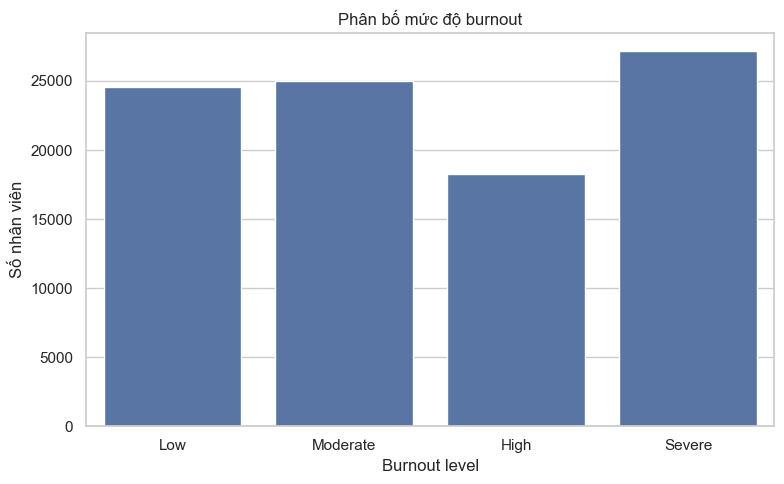

burnout_level
Low         25.86
Moderate    26.32
High        19.26
Severe      28.56
Name: proportion, dtype: float64

In [7]:
# EDA 4: Phân bố target burnout_level
burnout_order = ["Low", "Moderate", "High", "Severe"]
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x="burnout_level", order=burnout_order)
plt.title("Phân bố mức độ burnout")
plt.xlabel("Burnout level")
plt.ylabel("Số nhân viên")
plt.tight_layout()
plt.show()
data["burnout_level"].value_counts(normalize=True).reindex(burnout_order).mul(100).round(2)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_26844\717442132.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x="gender", order=gender_order, palette="pastel")


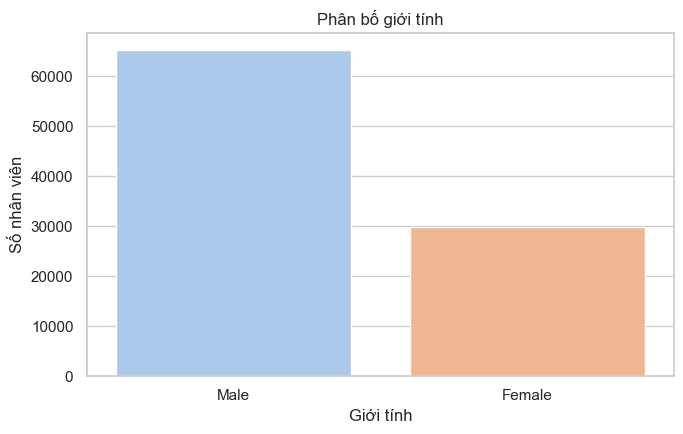

gender
Male      68.68
Female    31.32
Name: proportion, dtype: float64

In [8]:
# EDA 5.1: Phân bố theo giới tính
gender_order = ["Male", "Female"]
plt.figure(figsize=(7, 4.5))
sns.countplot(data=data, x="gender", order=gender_order, palette="pastel")
plt.title("Phân bố giới tính")
plt.xlabel("Giới tính")
plt.ylabel("Số nhân viên")
plt.tight_layout()
plt.show()

data["gender"].value_counts(normalize=True).reindex(gender_order).mul(100).round(2)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_26844\101694154.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, y="job_role", order=job_role_order, palette="magma")


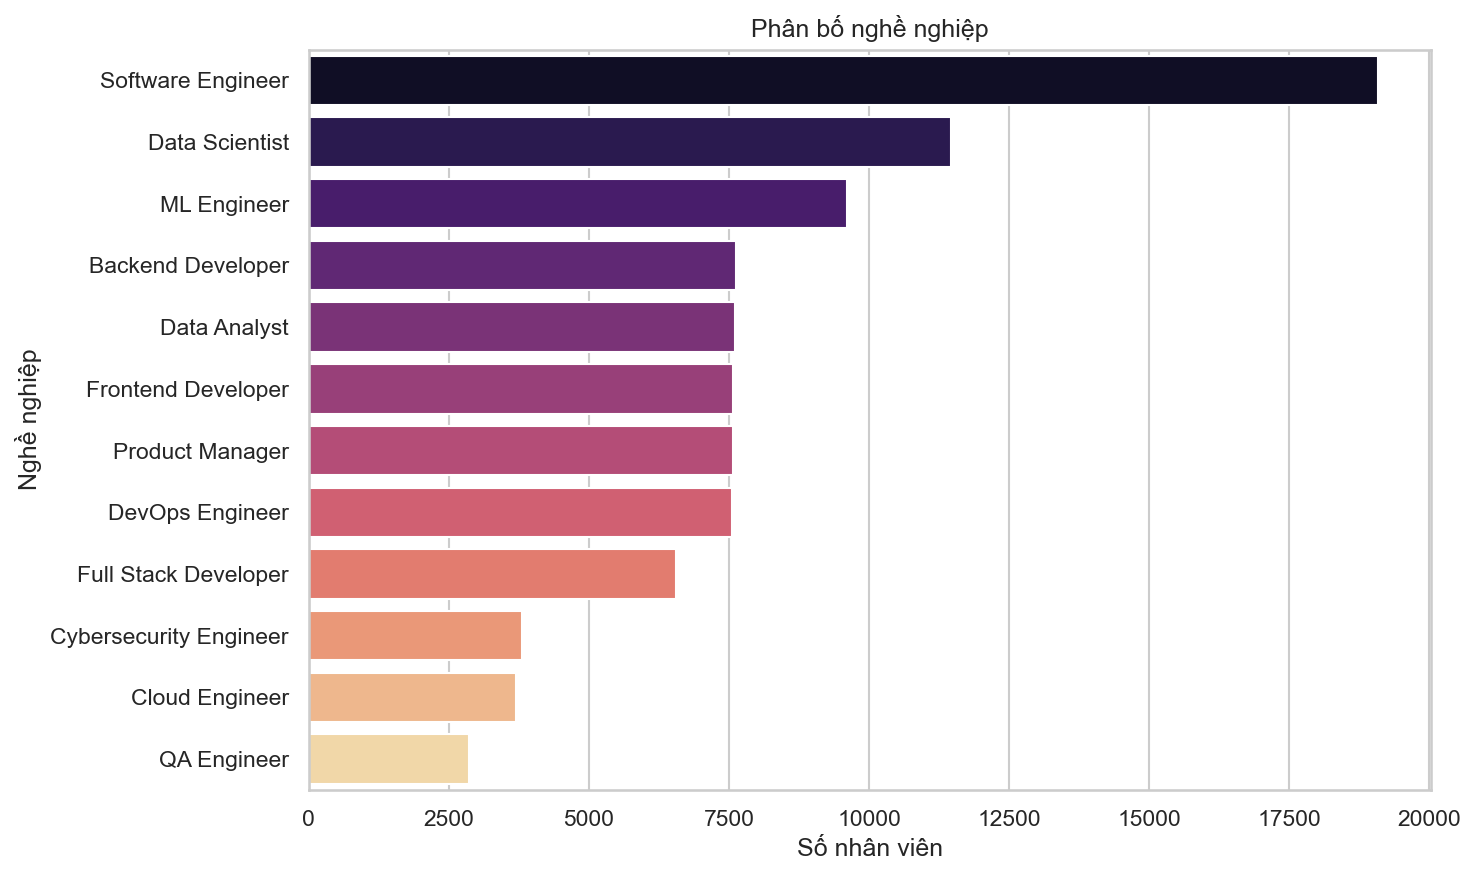

job_role
Software Engineer         20.08
Data Scientist            12.07
ML Engineer               10.12
Backend Developer          8.02
Data Analyst               8.01
Frontend Developer         7.97
Product Manager            7.96
DevOps Engineer            7.95
Full Stack Developer       6.90
Cybersecurity Engineer     4.00
Cloud Engineer             3.90
QA Engineer                3.02
Name: proportion, dtype: float64

In [16]:
# EDA 5.2: Phân bố theo nghề nghiệp
job_role_order = data["job_role"].value_counts().index
plt.figure(figsize=(10, 6))
sns.countplot(data=data, y="job_role", order=job_role_order, palette="magma")
plt.title("Phân bố nghề nghiệp")
plt.xlabel("Số nhân viên")
plt.ylabel("Nghề nghiệp")
plt.tight_layout()
plt.show()

data["job_role"].value_counts(normalize=True).mul(100).round(2)

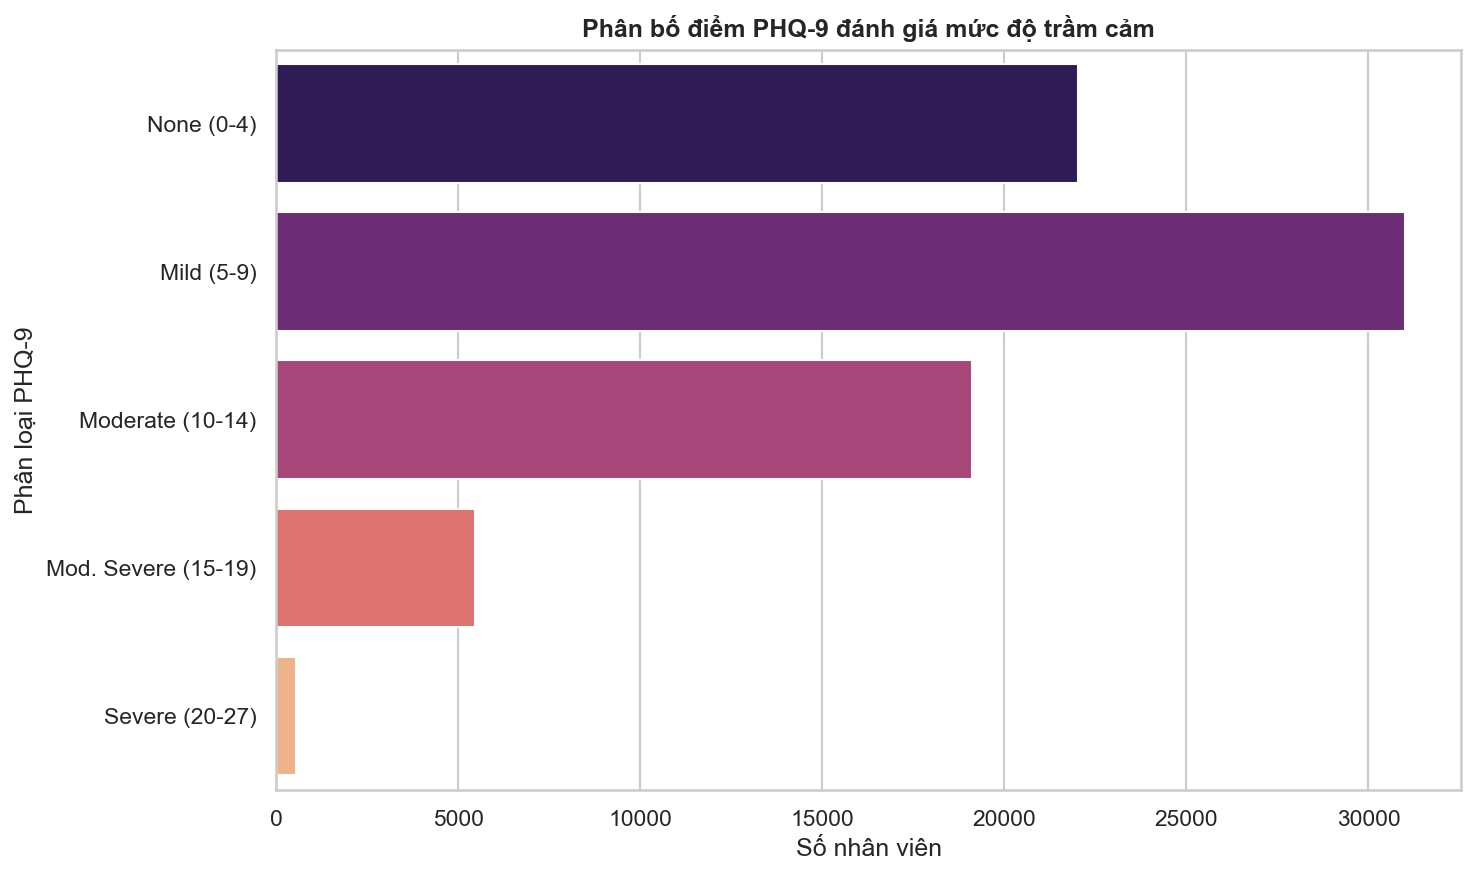

Tỷ lệ % PHQ-9:
phq9_group
Mild (5-9)             39.67
None (0-4)             28.18
Moderate (10-14)       24.46
Mod. Severe (15-19)     6.99
Severe (20-27)          0.70
Name: proportion, dtype: float64


In [25]:
# EDA 5.3: PHQ-9 (Patient Health Questionnaire-9) đánh giá mức độ trầm cảm.
phq9_bins = [0, 4, 9, 14, 19, 27]
phq9_labels = ["None (0-4)", "Mild (5-9)", "Moderate (10-14)", "Mod. Severe (15-19)", "Severe (20-27)"]

data["phq9_group"] = pd.cut(data["phq9_score"], bins=phq9_bins, labels=phq9_labels)
phq9_order = data["phq9_group"].value_counts().index

plt.figure(figsize=(10, 6))
sns.countplot(
    data=data, 
    y="phq9_group", 
    order=phq9_labels, 
    hue="phq9_group", 
    palette="magma", 
    legend=False
)
plt.title("Phân bố điểm PHQ-9 đánh giá mức độ trầm cảm", fontweight="bold")
plt.xlabel("Số nhân viên")
plt.ylabel("Phân loại PHQ-9")
plt.tight_layout()
plt.show()

print("Tỷ lệ % PHQ-9:")
print(data["phq9_group"].value_counts(normalize=True).mul(100).round(2))

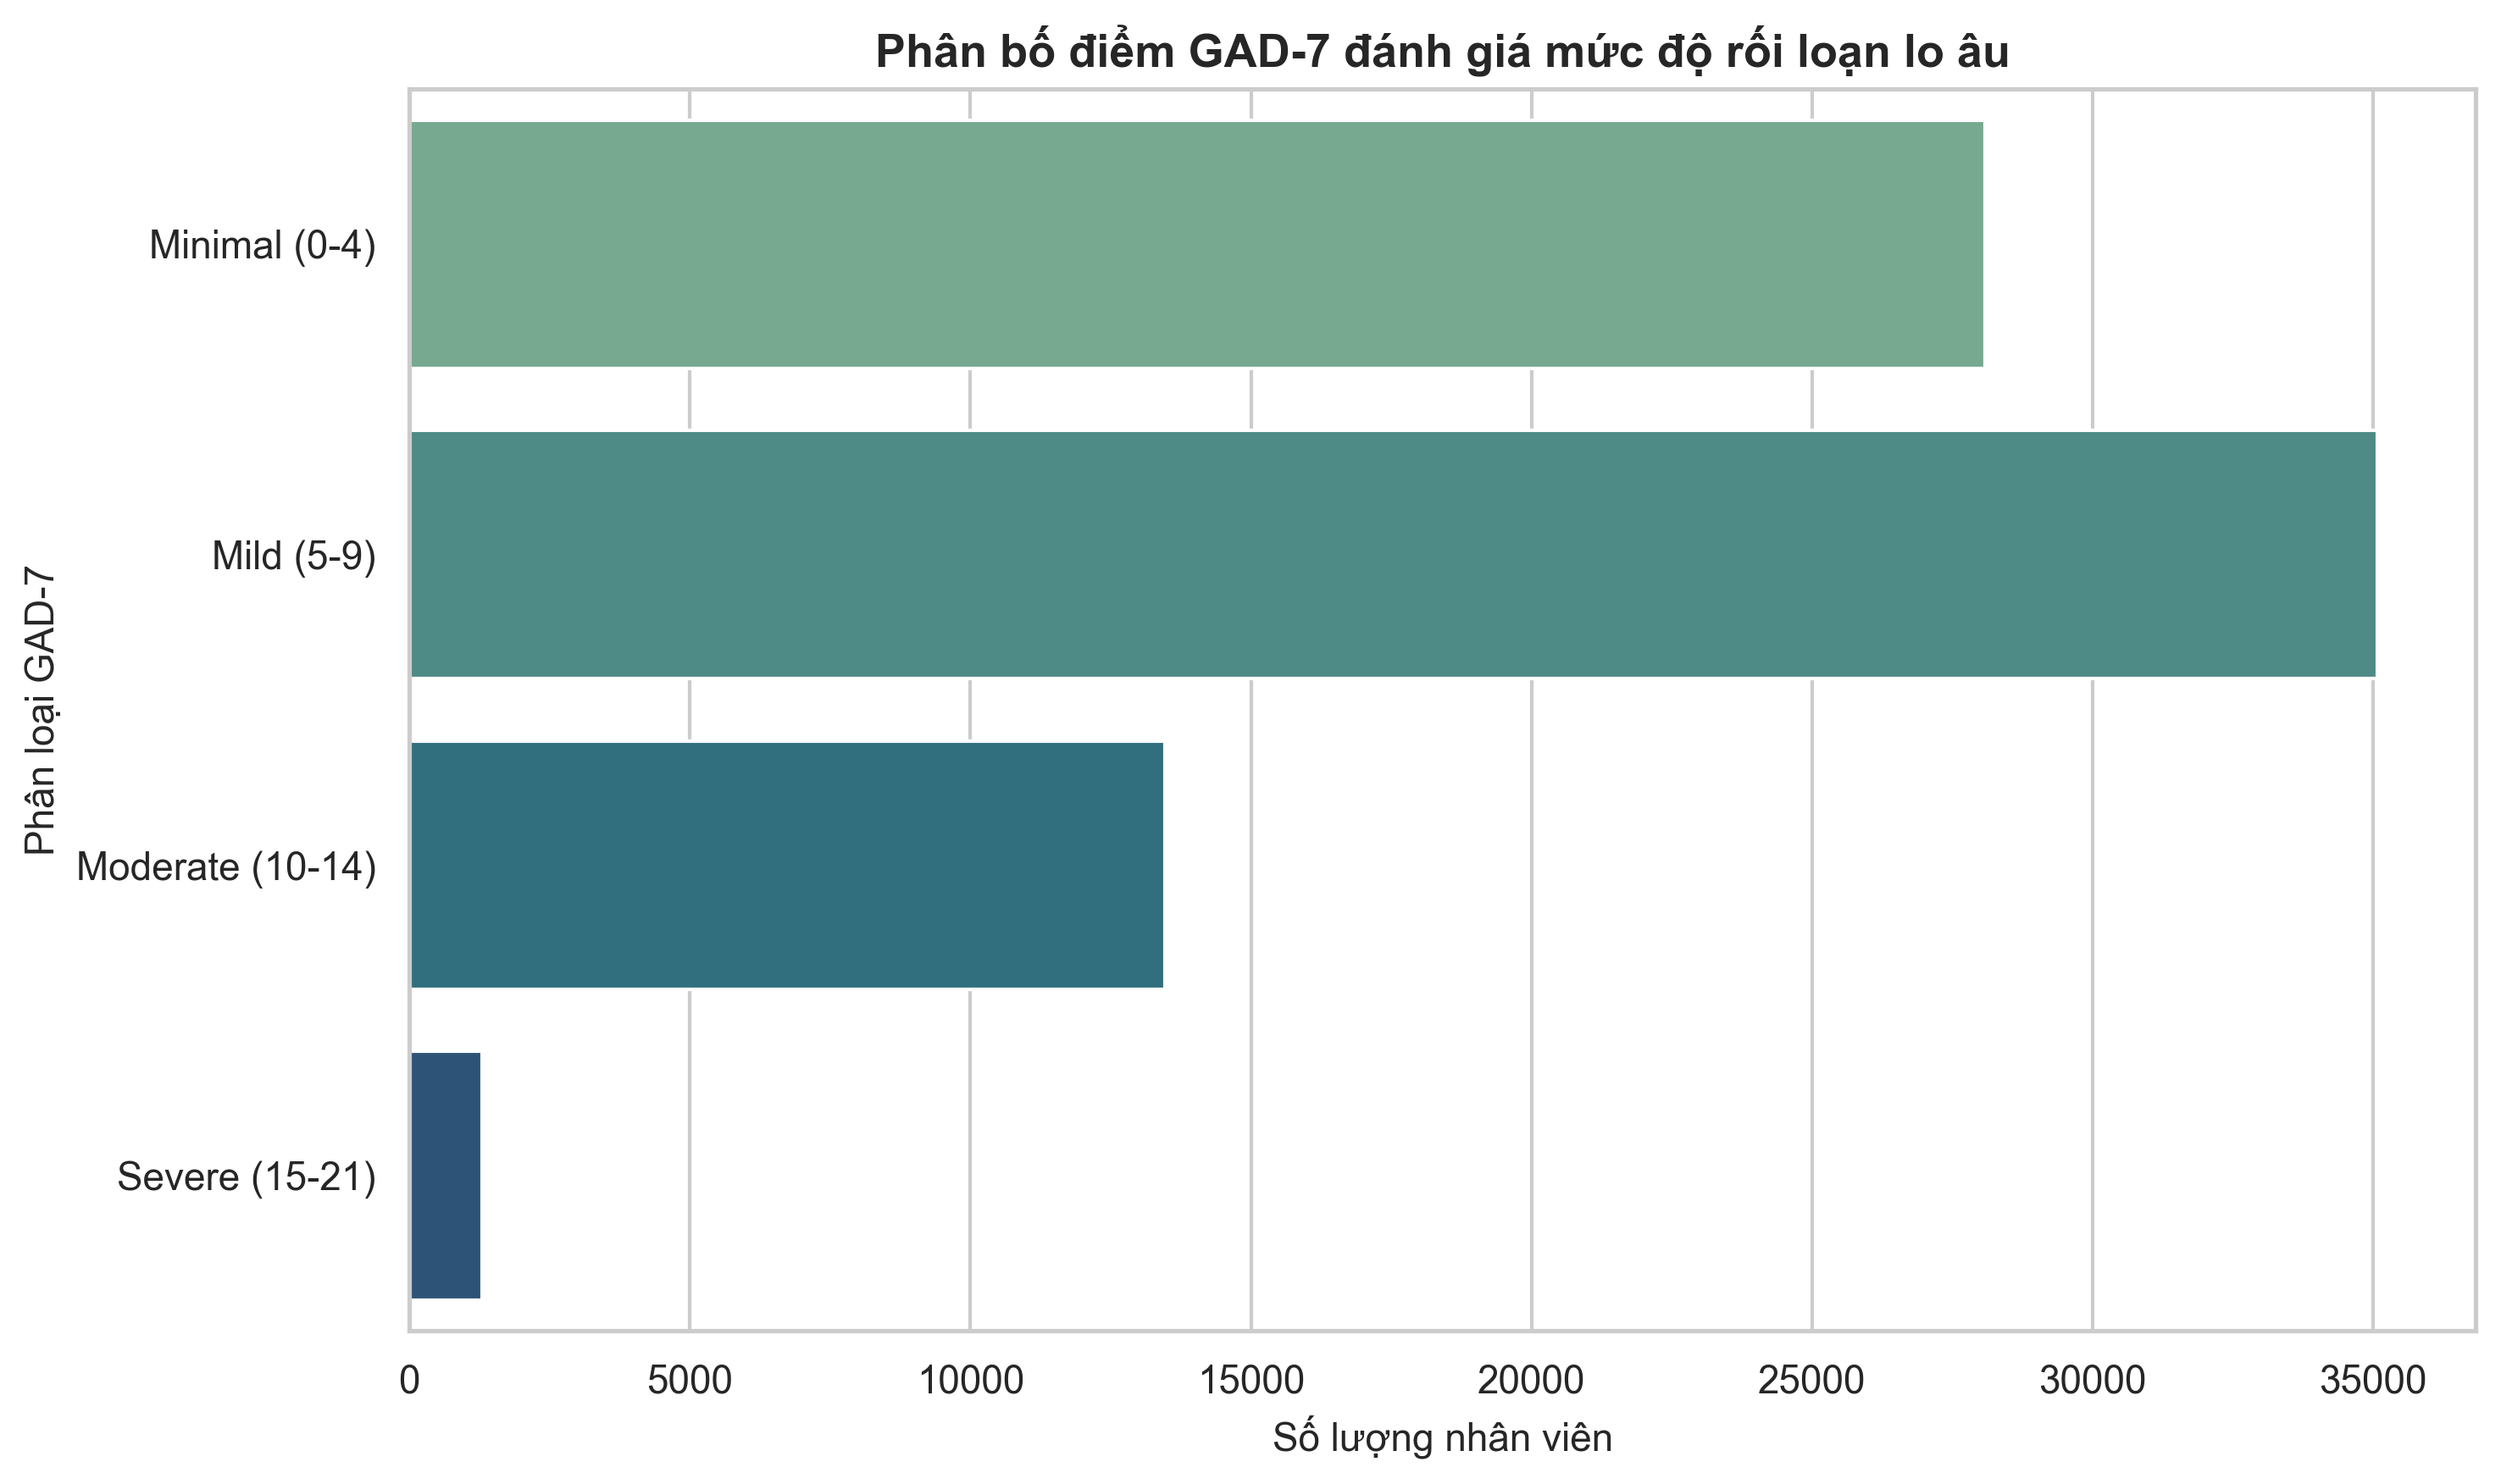

Tỷ lệ % GAD-7:
gad7_group
Minimal (0-4)       36.04
Mild (5-9)          45.00
Moderate (10-14)    17.29
Severe (15-21)       1.67
Name: proportion, dtype: float64


In [24]:
# EDA 5.4: GAD-7 (Generalized Anxiety Disorder-7) đánh giá mức độ rối loạn lo âu.
gad7_bins = [0, 4, 9, 14, 21]
gad7_labels = ["Minimal (0-4)", "Mild (5-9)", "Moderate (10-14)", "Severe (15-21)"]

data["gad7_group"] = pd.cut(data["gad7_score"], bins=gad7_bins, labels=gad7_labels)

plt.figure(figsize=(10, 6), dpi=300)
sns.countplot(
    data=data, 
    y="gad7_group", 
    order=gad7_labels, 
    hue="gad7_group", 
    palette="crest", 
    legend=False
)
plt.title("Phân bố điểm GAD-7 đánh giá mức độ rối loạn lo âu", fontweight="bold", fontsize=13)
plt.xlabel("Số lượng nhân viên", fontsize=11)
plt.ylabel("Phân loại GAD-7", fontsize=11)
plt.tight_layout()
plt.show()

print("Tỷ lệ % GAD-7:")
gad7_pct = data["gad7_group"].value_counts(normalize=True).mul(100).round(2)
print(gad7_pct.loc[gad7_labels])

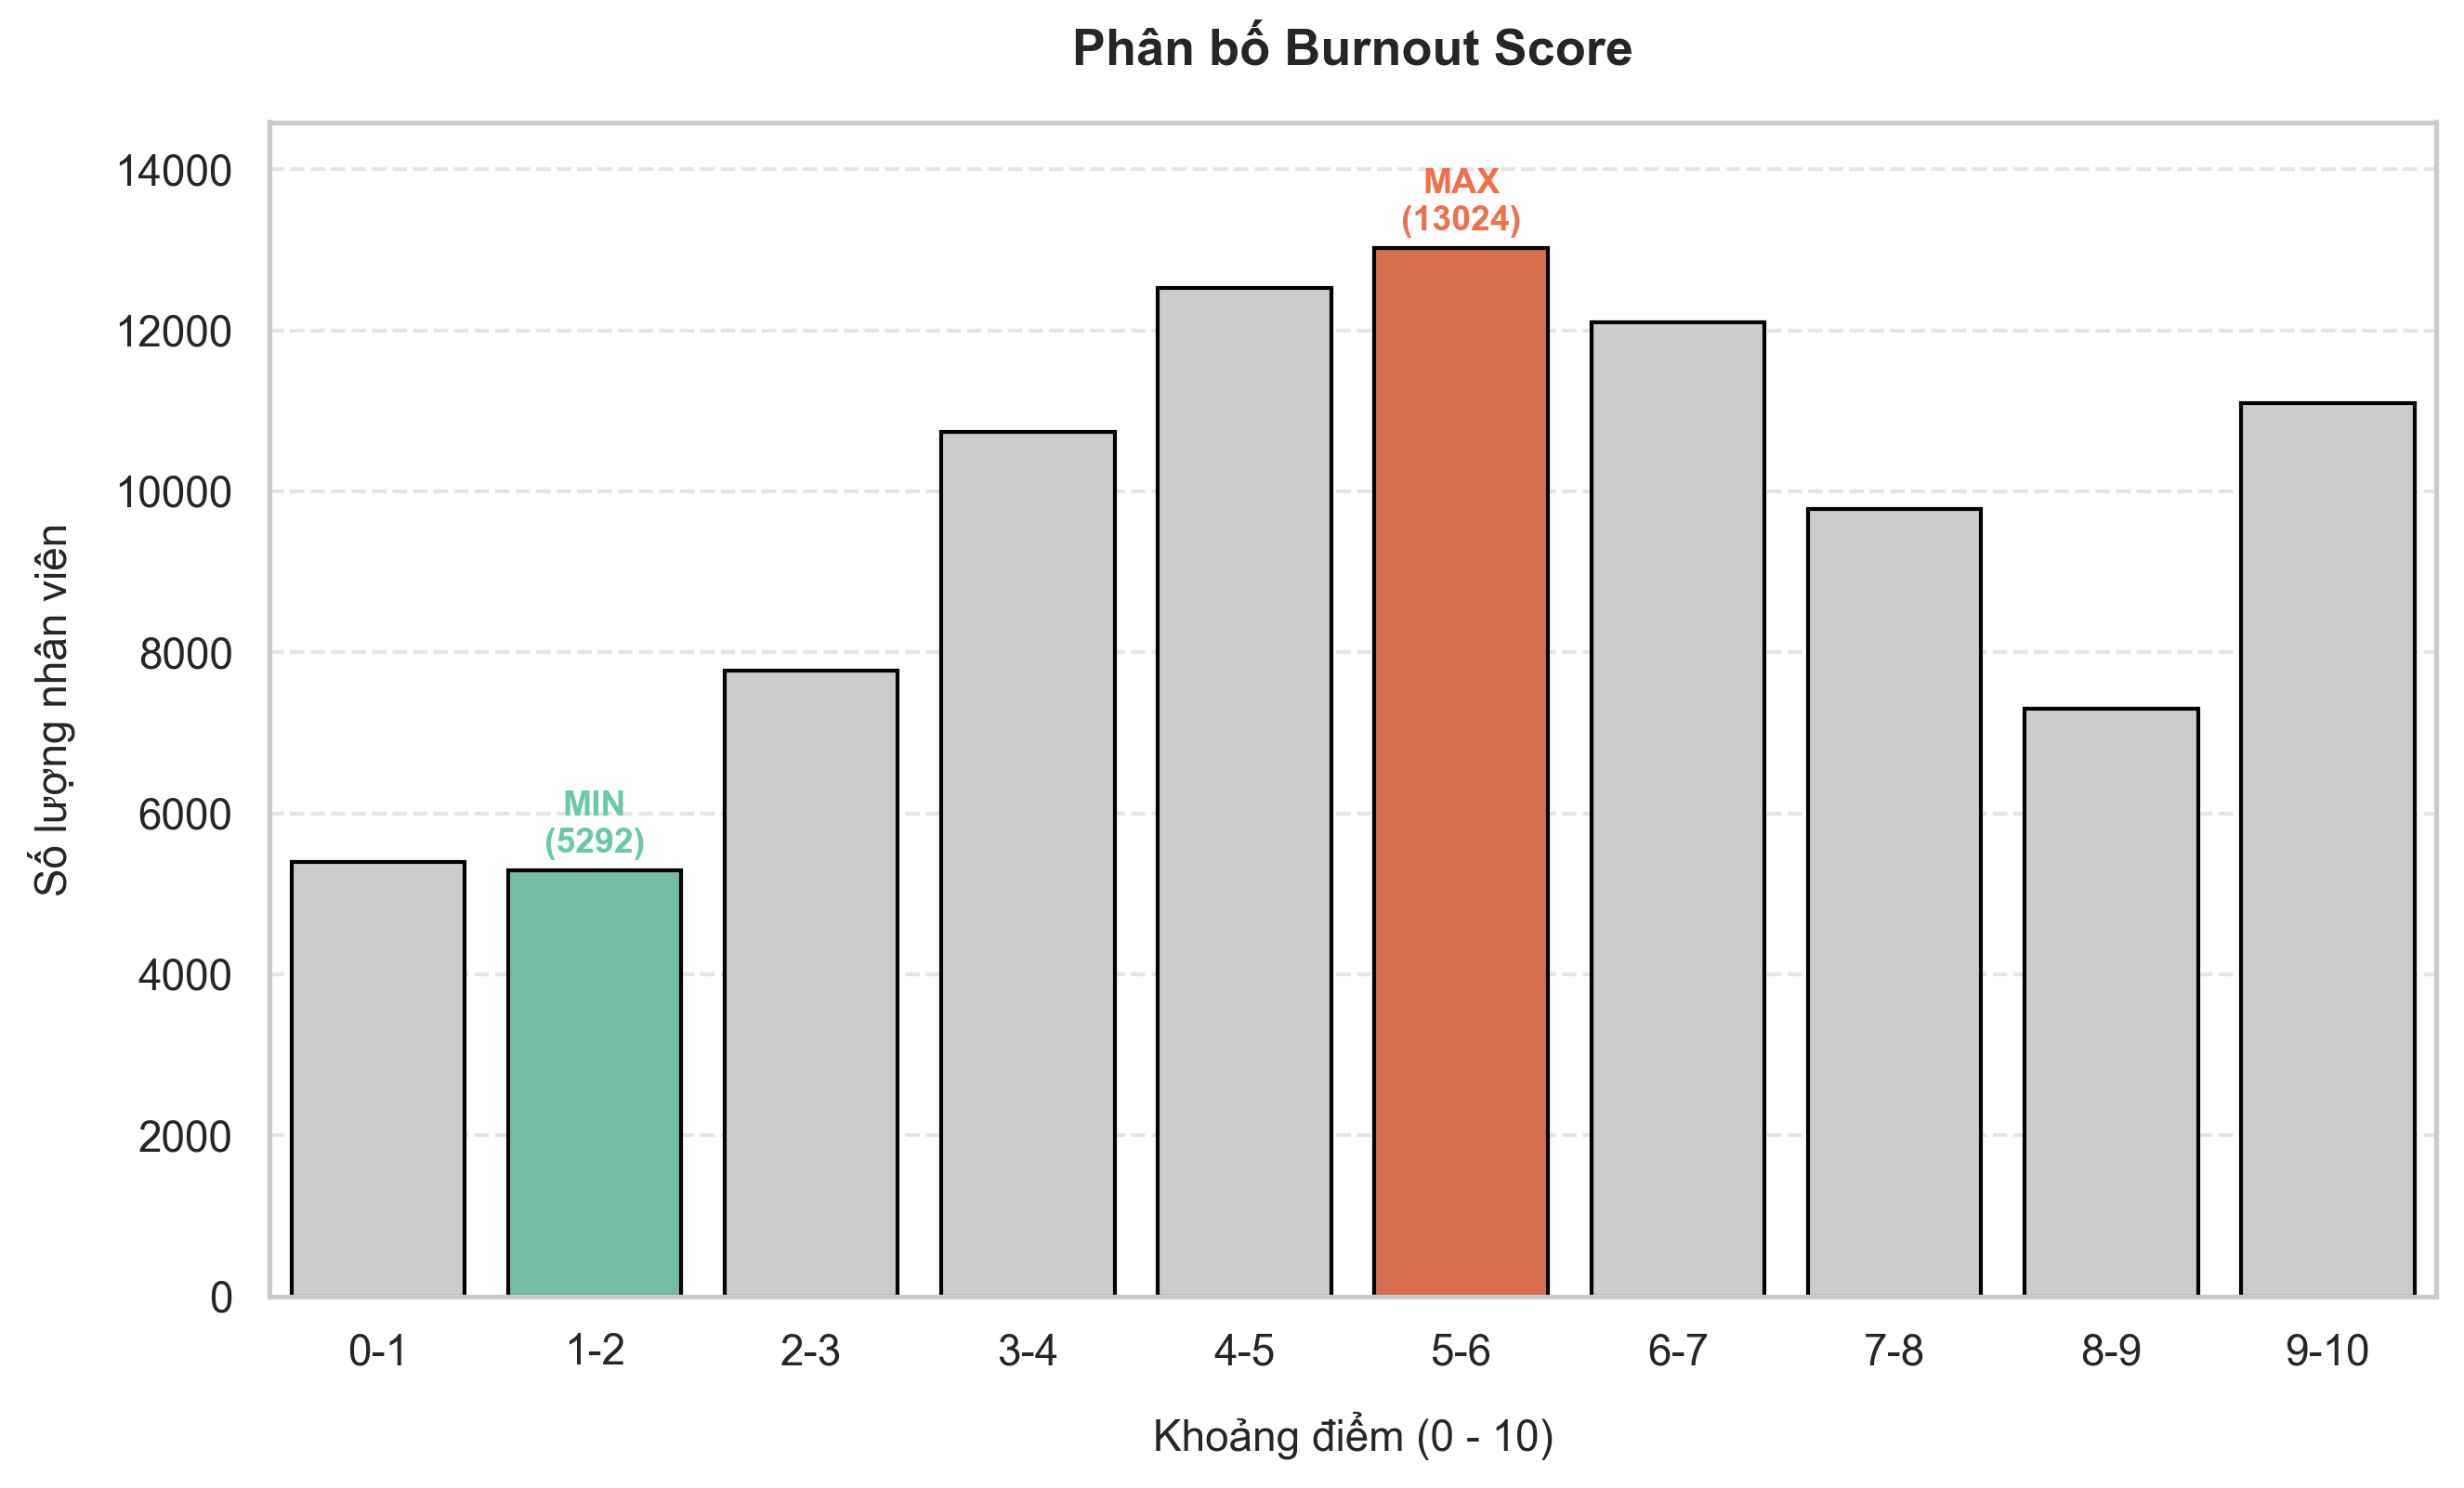

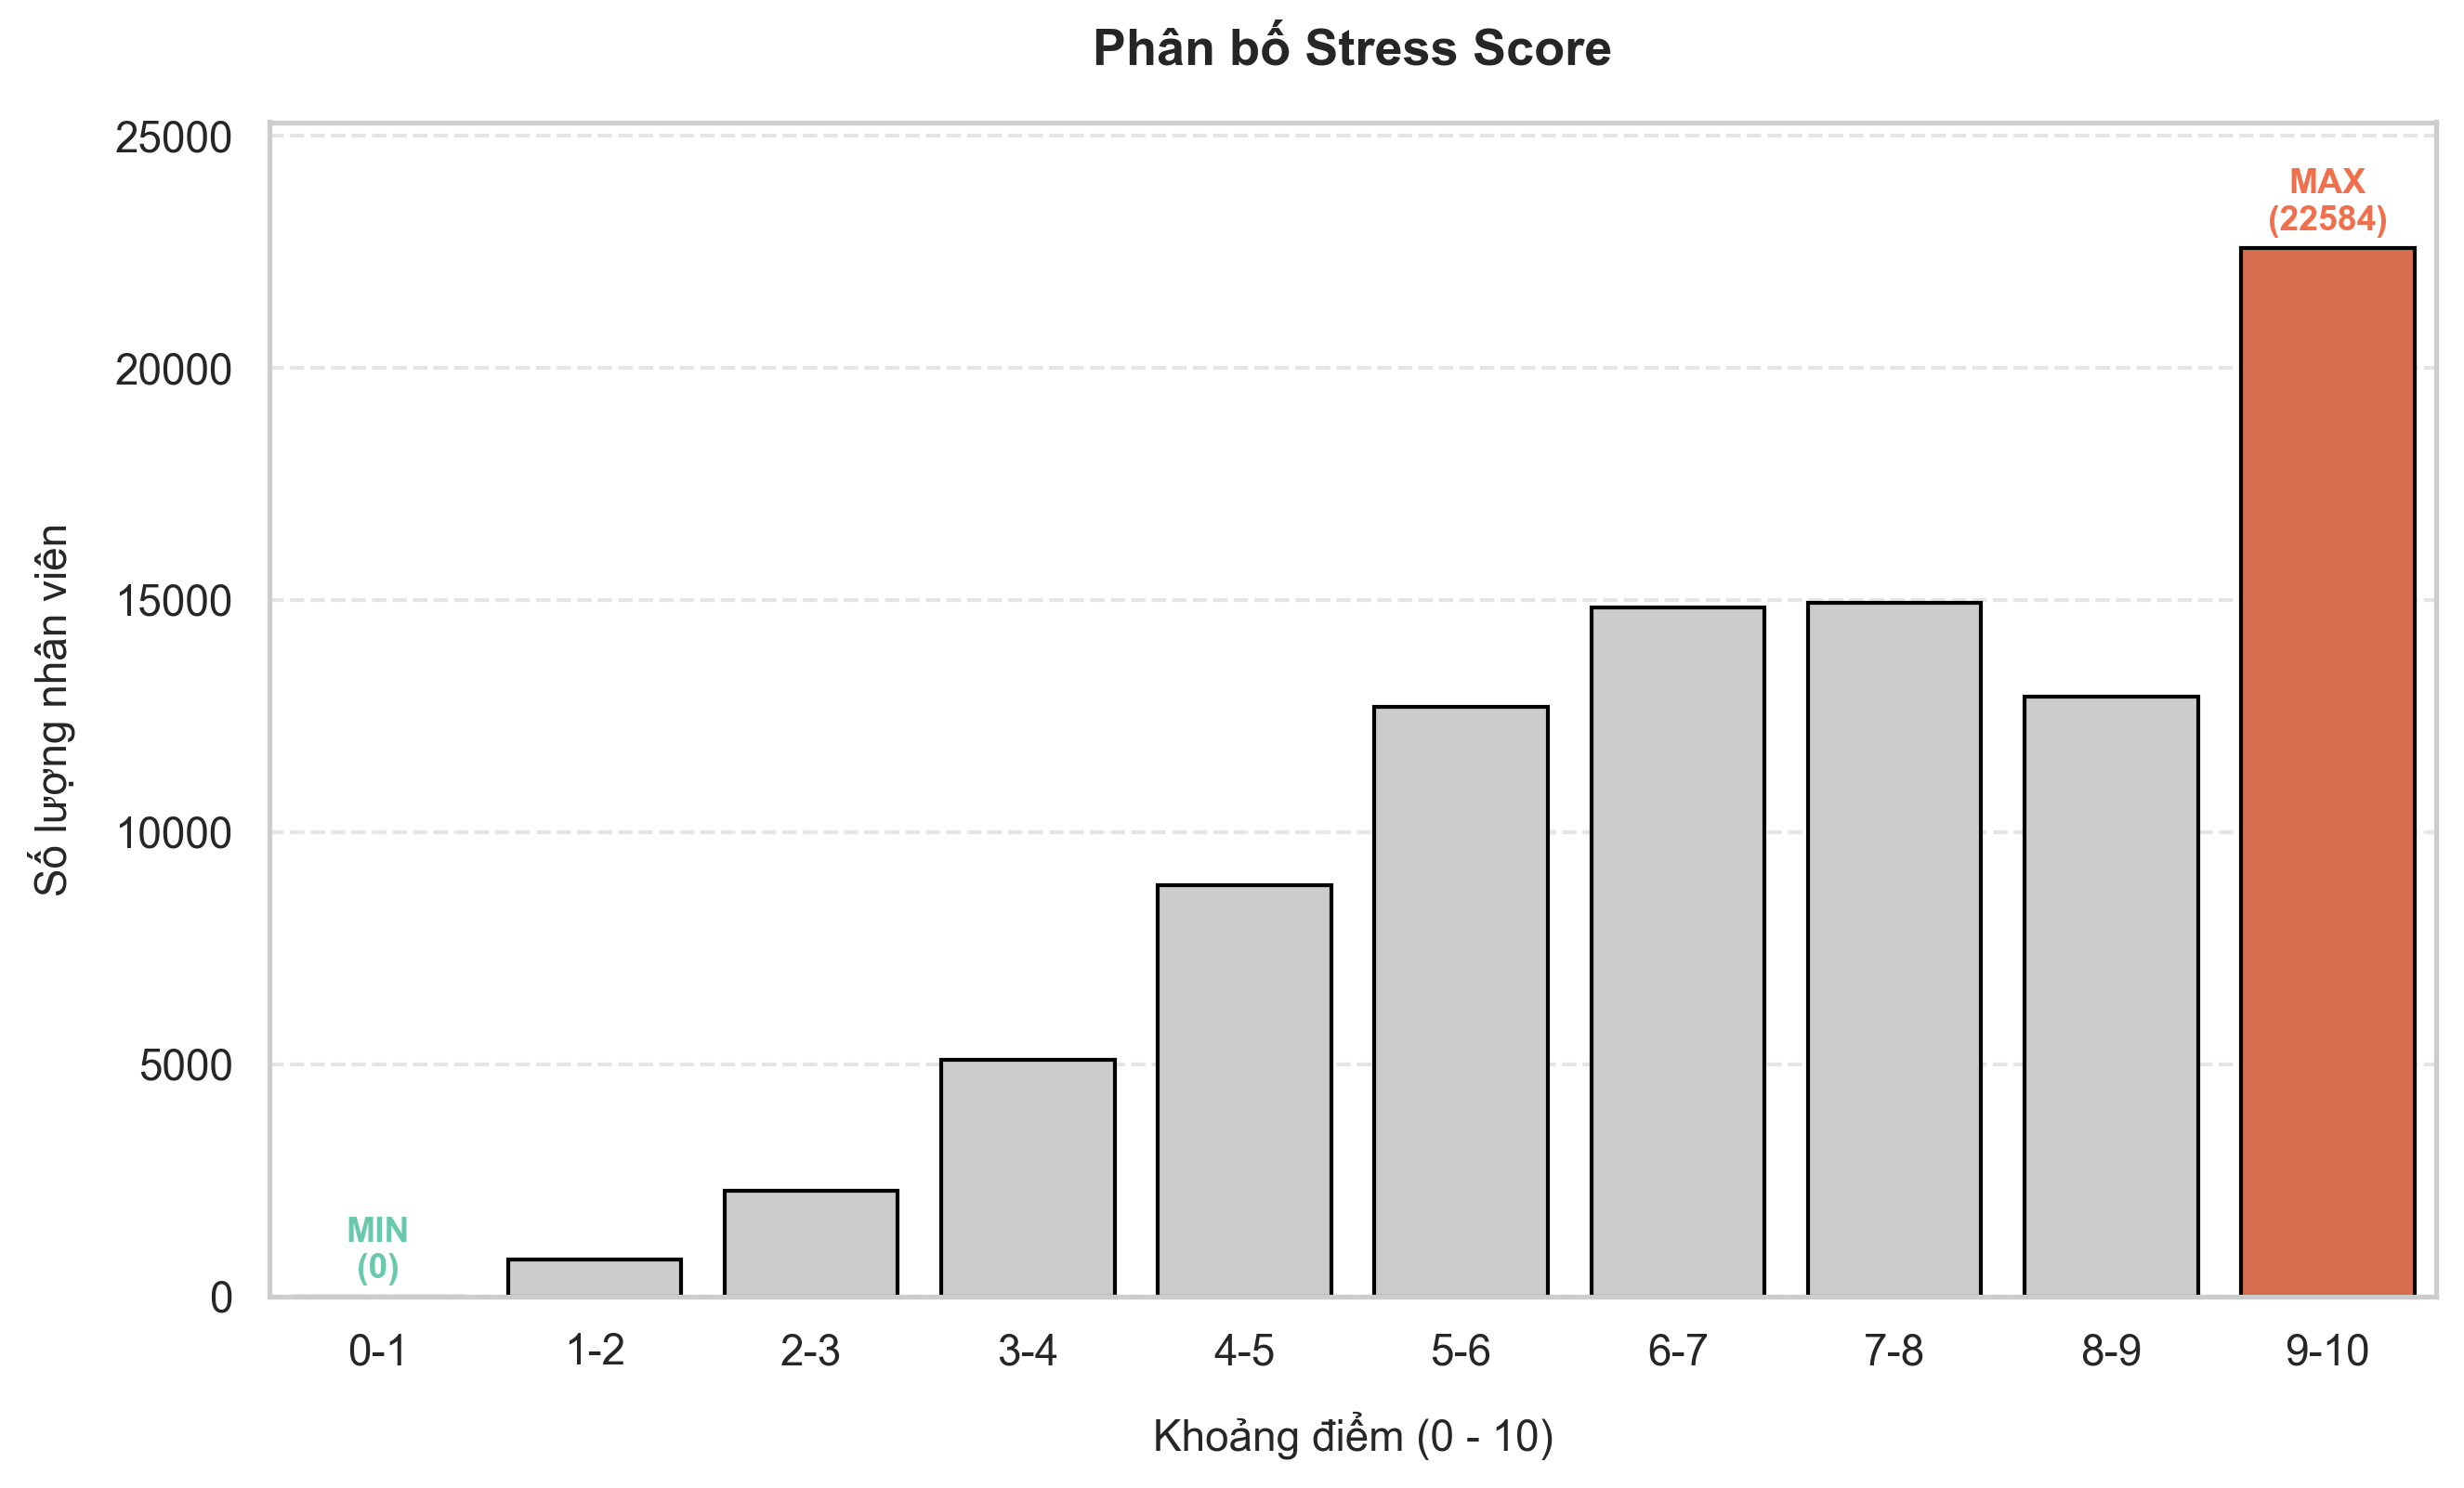

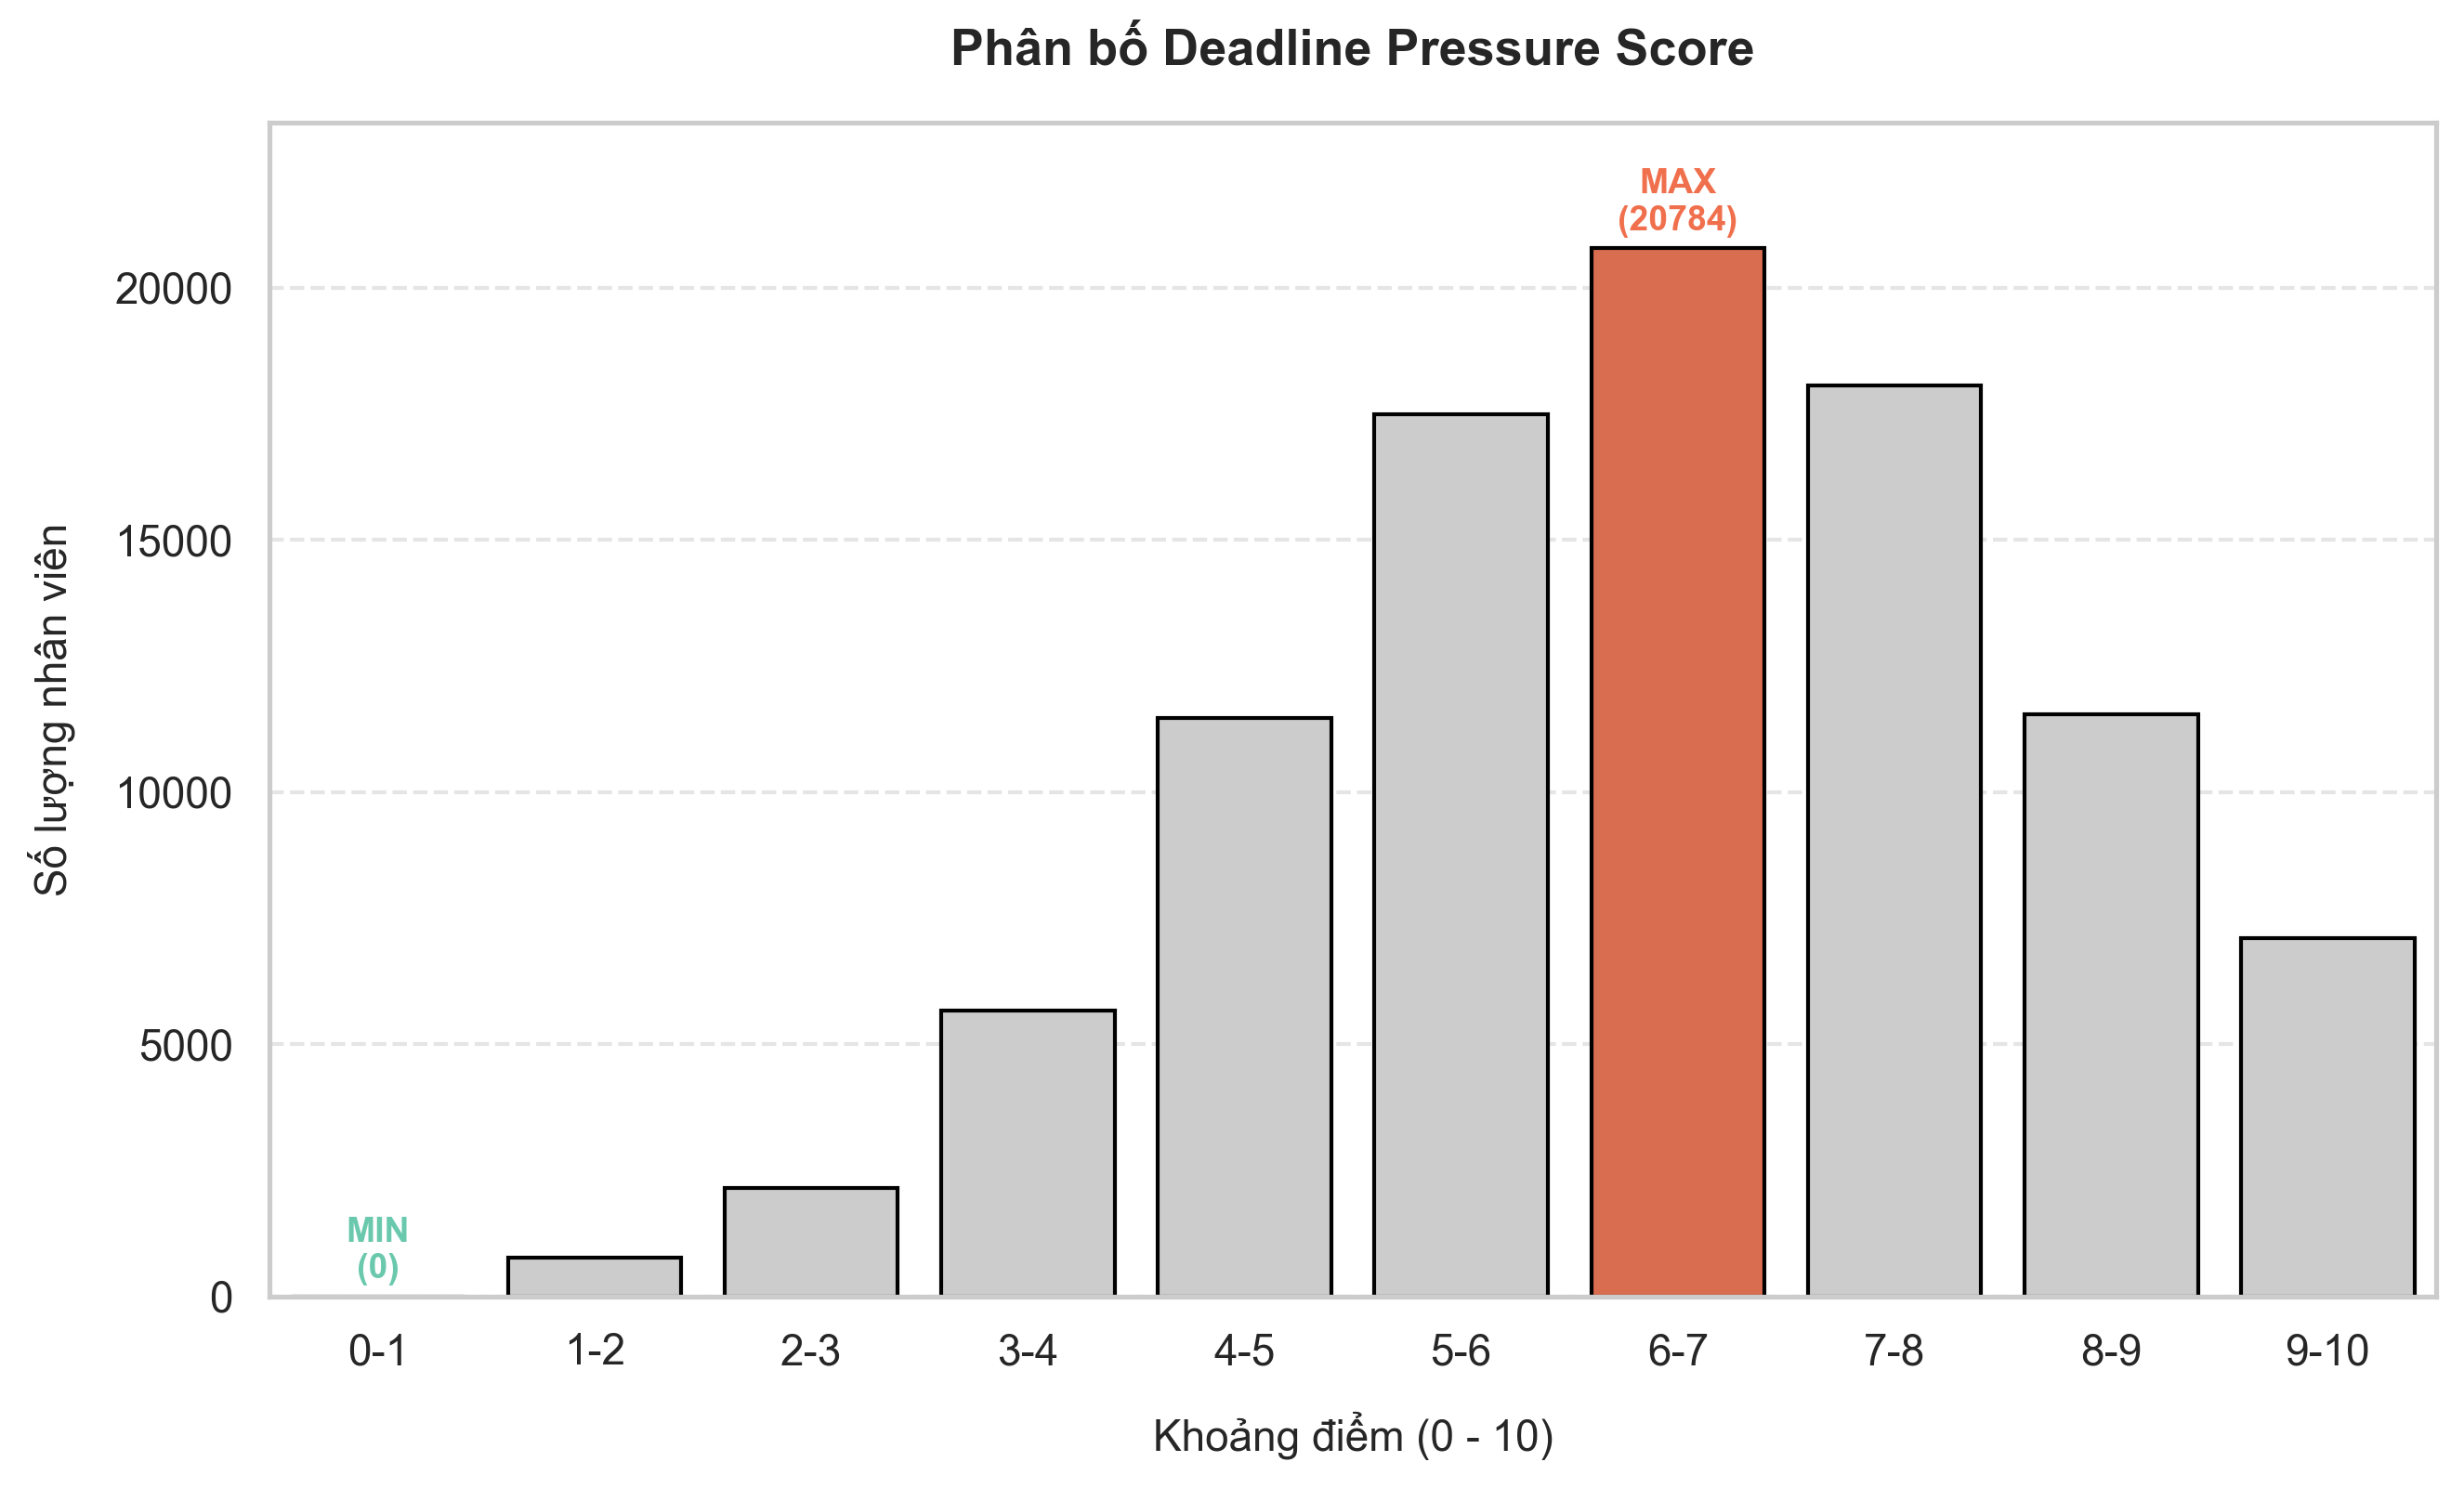

In [38]:
# EDA 5.5: Các điểm số liên tục trên thang 0-10
bins_10 = np.linspace(0, 10, 11)
continuous_cols = [
    ("burnout_score", "Burnout Score"),
    ("stress_score", "Stress Score"),
    ("deadline_pressure_score", "Deadline Pressure Score")
]

for column, title in continuous_cols:
    plt.figure(figsize=(9, 5.5), dpi=300)
    
    counts, bin_edges = np.histogram(data[column].dropna(), bins=bins_10)
    bin_labels = [f"{int(bin_edges[i])}-{int(bin_edges[i+1])}" for i in range(len(counts))]
    
    max_idx = np.argmax(counts)
    min_idx = np.argmin(counts)
    
    bar_colors = []
    for i in range(len(counts)):
        if i == max_idx:
            bar_colors.append("#ef6039e7")
        elif i == min_idx:
            bar_colors.append("#6ac8ac")
        else:
            bar_colors.append("#cccccc")
            
    ax = sns.barplot(
        x=bin_labels,
        y=counts,
        hue=bin_labels,
        palette=bar_colors,
        legend=False,
        edgecolor="black"
    )
    
    for i, count in enumerate(counts):
        if i == max_idx or i == min_idx:
            ax.text(
                i, count + (max(counts) * 0.01), 
                f"{'MAX' if i == max_idx else 'MIN'}\n({count})", 
                ha="center", va="bottom", fontweight="bold", fontsize=9,
                color="#ef6039e7" if i == max_idx else "#6ac8ac"
            )
            
    plt.title(f"Phân bố {title}", fontweight="bold", fontsize=13, pad=15)
    plt.xlabel("Khoảng điểm (0 - 10)", fontsize=11, labelpad=10)
    plt.ylabel("Số lượng nhân viên", fontsize=11, labelpad=10)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.ylim(0, max(counts) * 1.12)
    plt.tight_layout()
    plt.show()

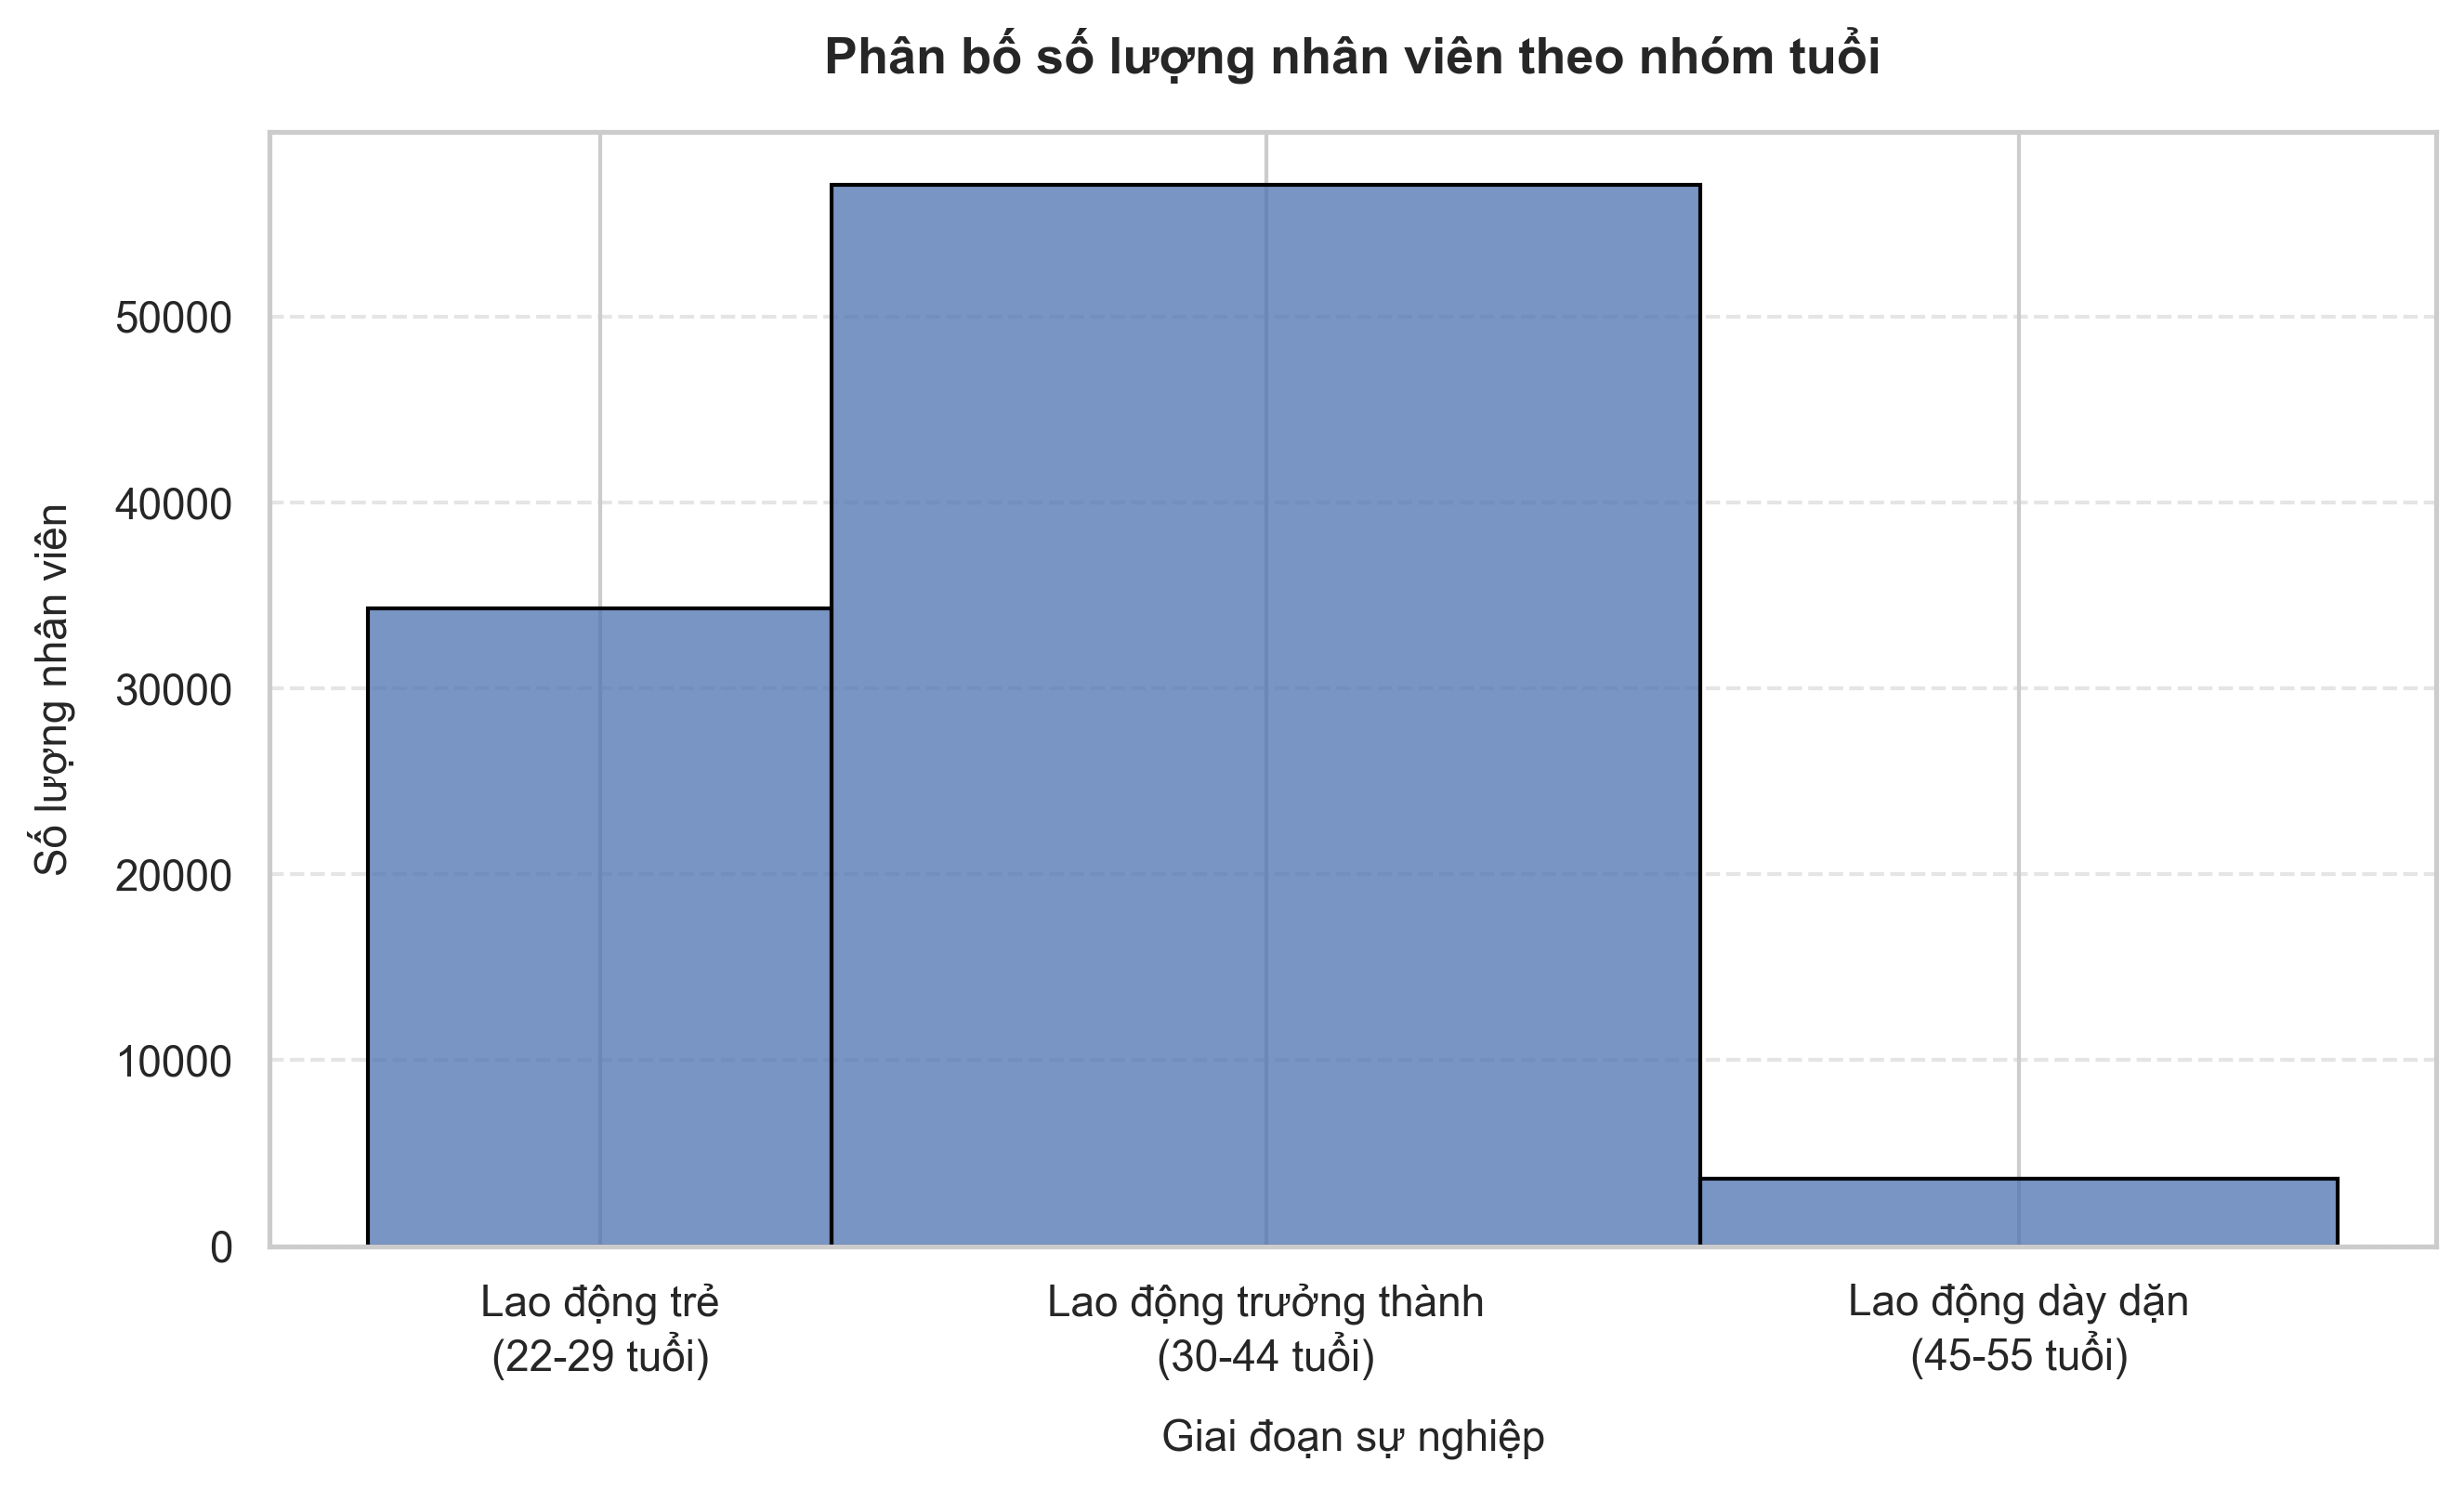

In [42]:
# EDA 5.6: Phân bố theo tuỏio
age_bins = [21, 29, 44, 55]
bin_centers = [25.0, 36.5, 49.5]
bin_labels = ["Lao động trẻ\n(22-29 tuổi)", "Lao động trưởng thành\n(30-44 tuổi)", "Lao động dày dặn\n(45-55 tuổi)"]
plt.figure(figsize=(9, 5.5), dpi=300)
sns.histplot(data=data, x="age", bins=age_bins, edgecolor="black")
plt.title("Phân bố số lượng nhân viên theo nhóm tuổi", fontweight="bold", fontsize=13, pad=15)
plt.xlabel("Giai đoạn sự nghiệp", fontsize=11, labelpad=10)
plt.ylabel("Số lượng nhân viên", fontsize=11, labelpad=10)
plt.xticks(bin_centers, bin_labels)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

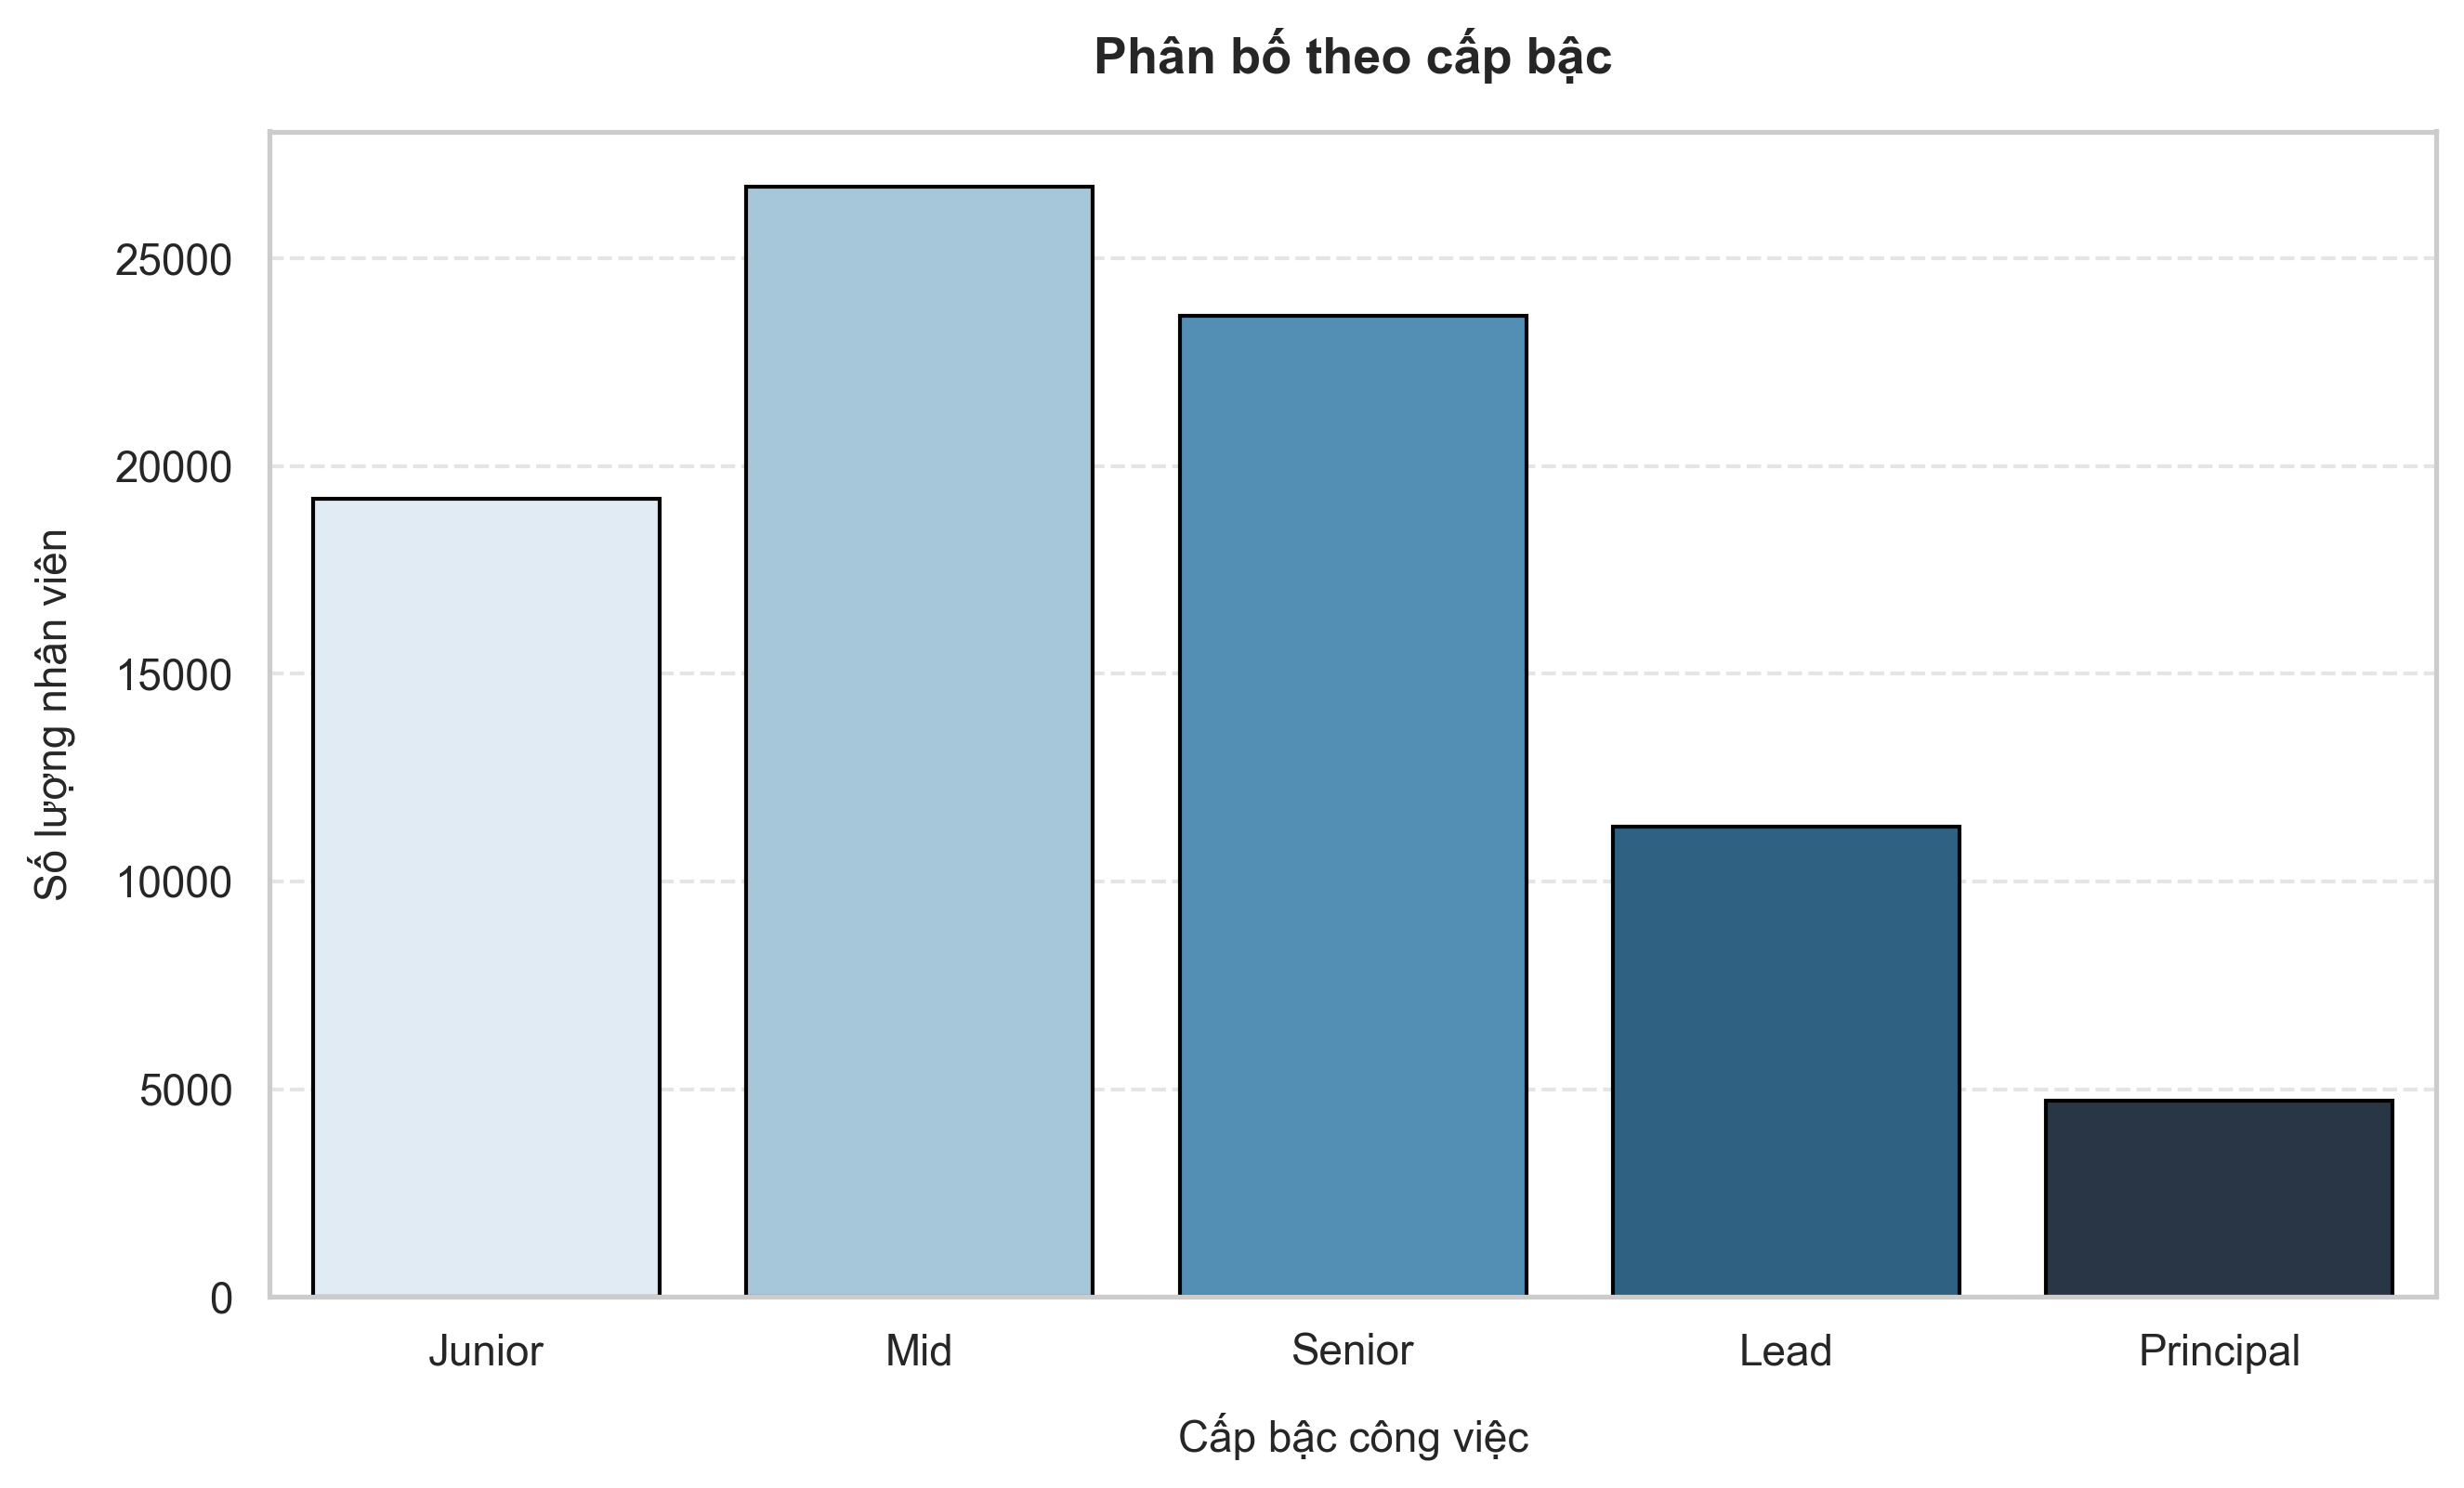

In [46]:
# EDA 5.7: Phân bố theo cấp bậc
plt.figure(figsize=(9, 5.5), dpi=300)

seniority_order = ["Junior", "Mid", "Senior", "Lead", "Principal"]
valid_order = [level for level in seniority_order if level in data["seniority_level"].unique()]

blues_gradient = ["#deebf7", "#9ecae1", "#4292c6", "#216491", "#23364a"]

color_dict = dict(zip(seniority_order, blues_gradient))

sns.countplot(
    data=data,
    x="seniority_level",
    order=valid_order,
    hue="seniority_level",
    hue_order=valid_order,
    palette=color_dict,
    legend=False,
    edgecolor="black"
)
plt.title("Phân bố theo cấp bậc", fontweight="bold", fontsize=13, pad=15)
plt.xlabel("Cấp bậc công việc", fontsize=11, labelpad=10)
plt.ylabel("Số lượng nhân viên", fontsize=11, labelpad=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

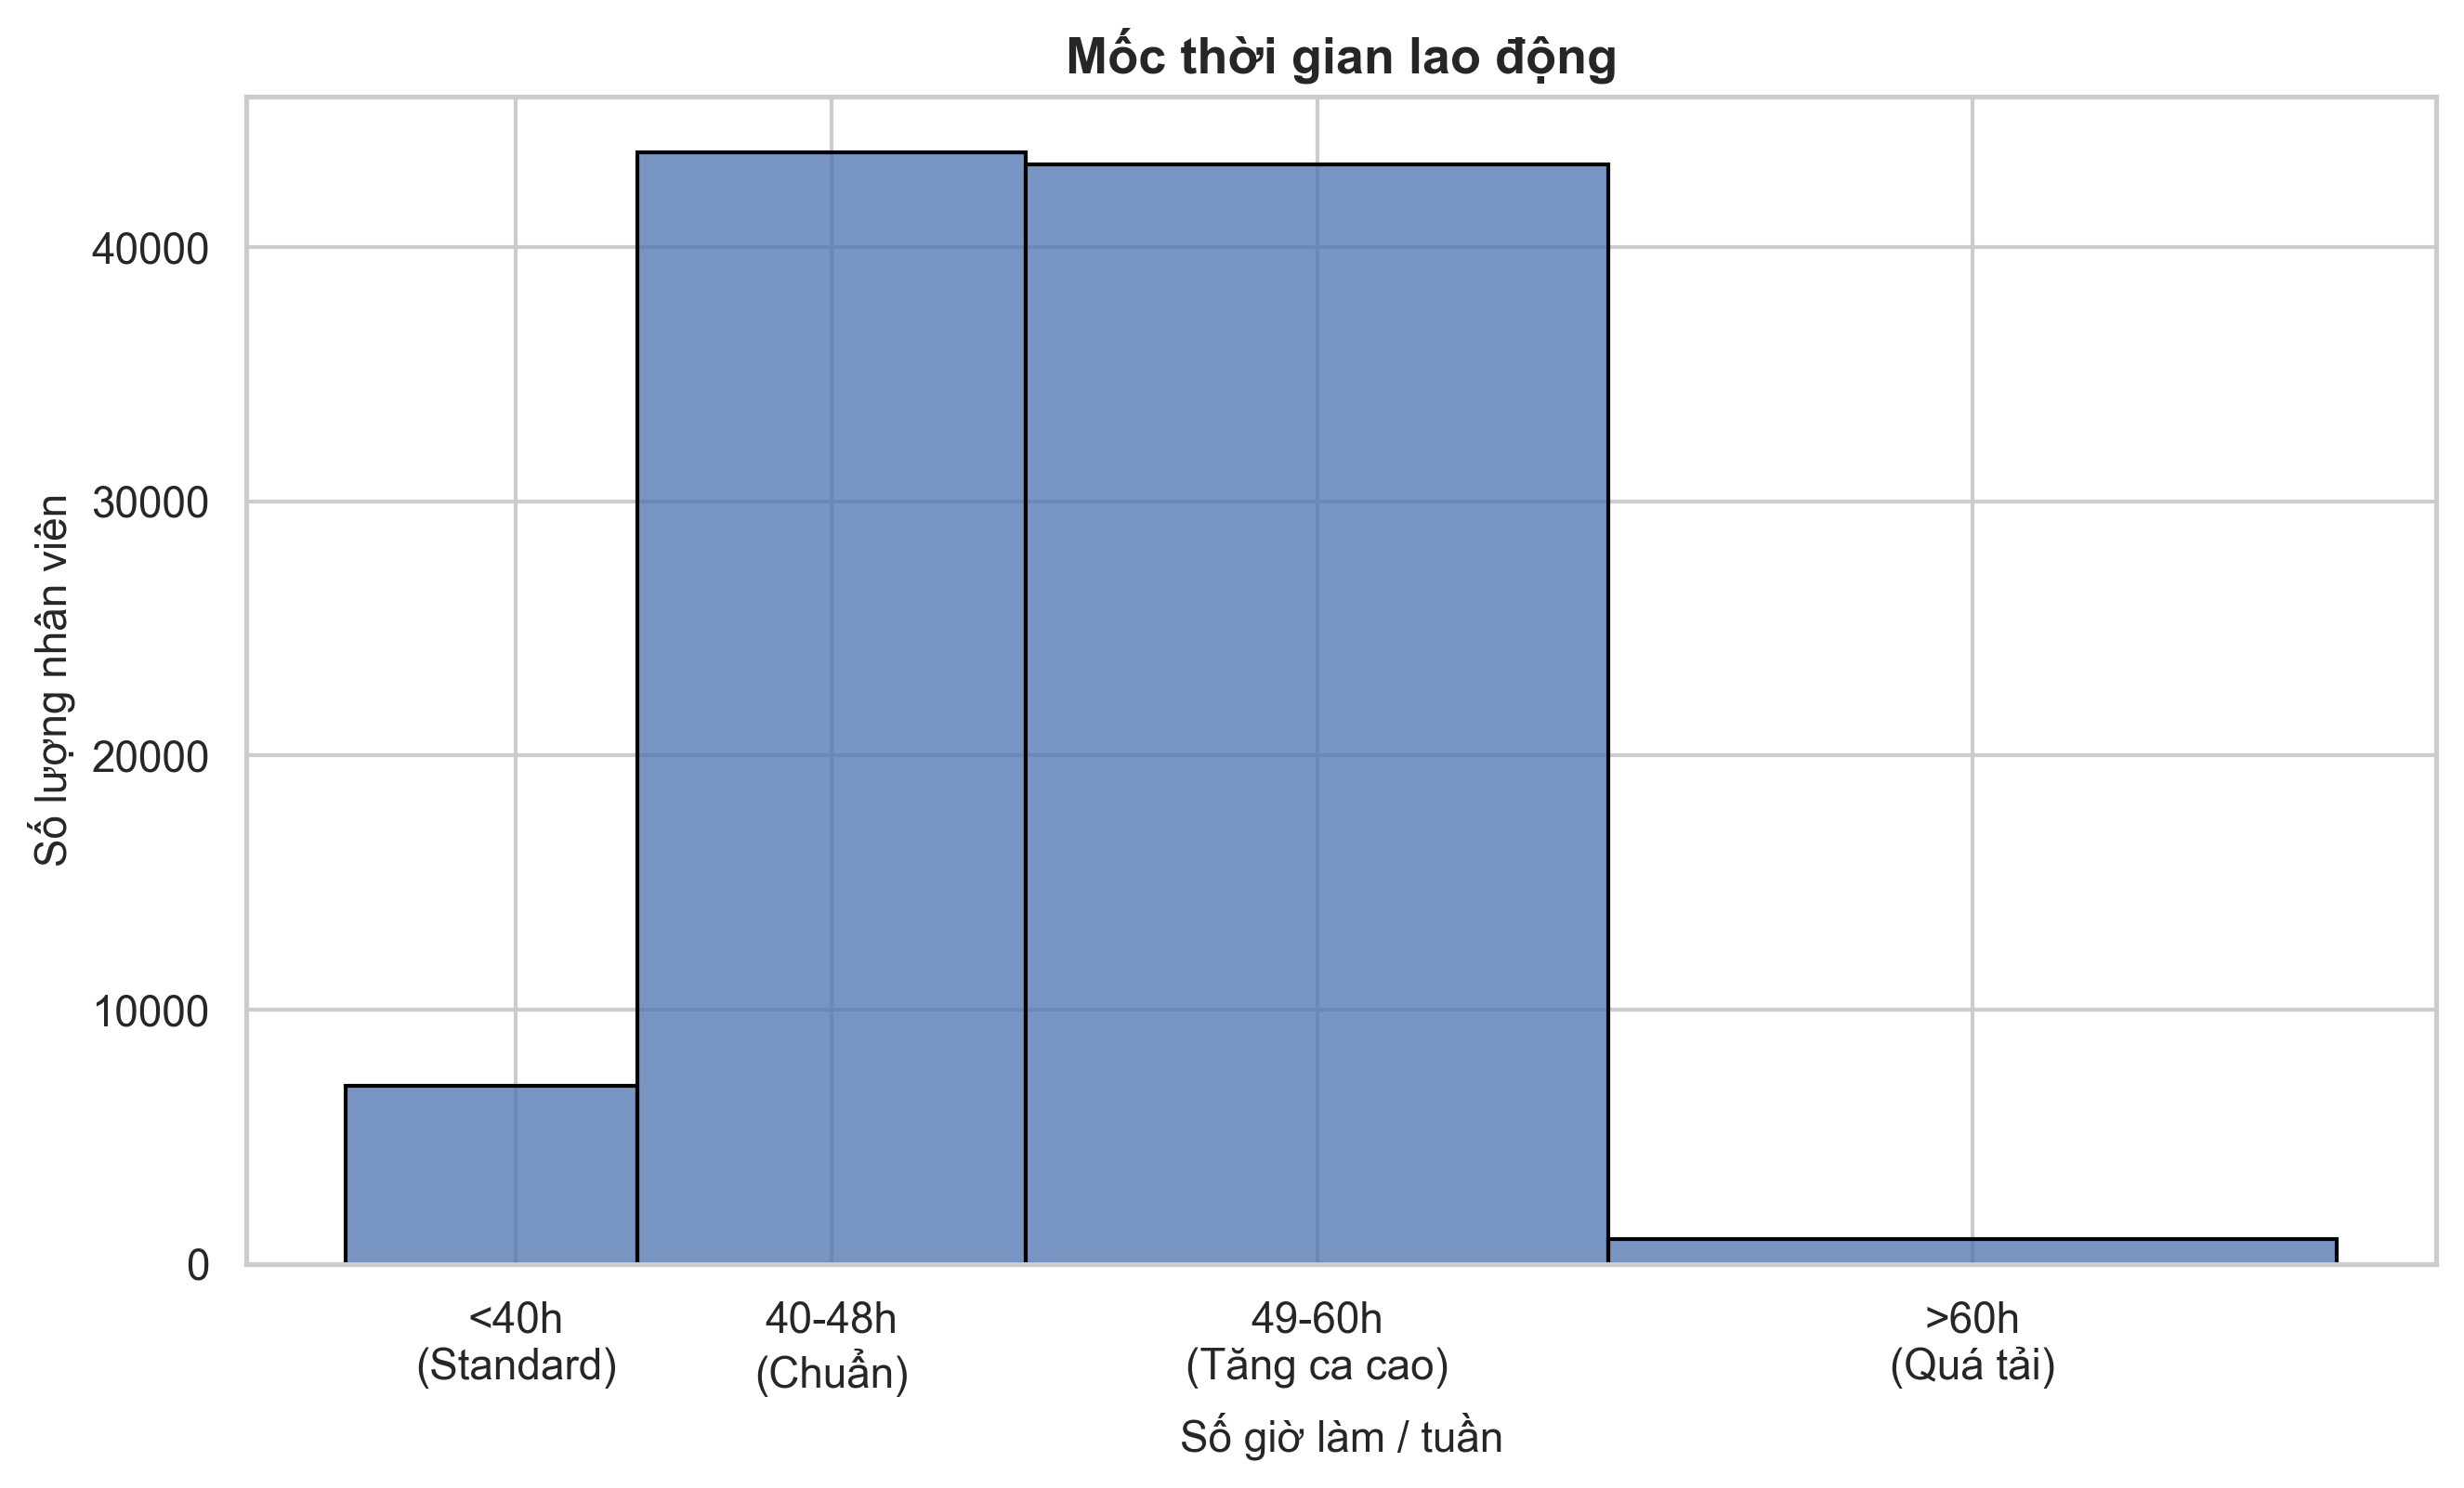

In [47]:
# EDA 5.8: Mốc thời gian lao động
work_bins = [34, 40, 48, 60, 75]
plt.figure(figsize=(9, 5.5), dpi=300)
sns.histplot(data=data, x="work_hours_per_week", bins=work_bins, edgecolor="black")
plt.title("Mốc thời gian lao động", fontweight="bold", fontsize=13)
plt.xlabel("Số giờ làm / tuần", fontsize=11)
plt.ylabel("Số lượng nhân viên", fontsize=11)
plt.xticks(
    [37.5, 44, 54, 67.5],
    ["<40h\n(Standard)", "40-48h\n(Chuẩn)", "49-60h\n(Tăng ca cao)", ">60h\n(Quá tải)"]
)
plt.tight_layout()
plt.show()


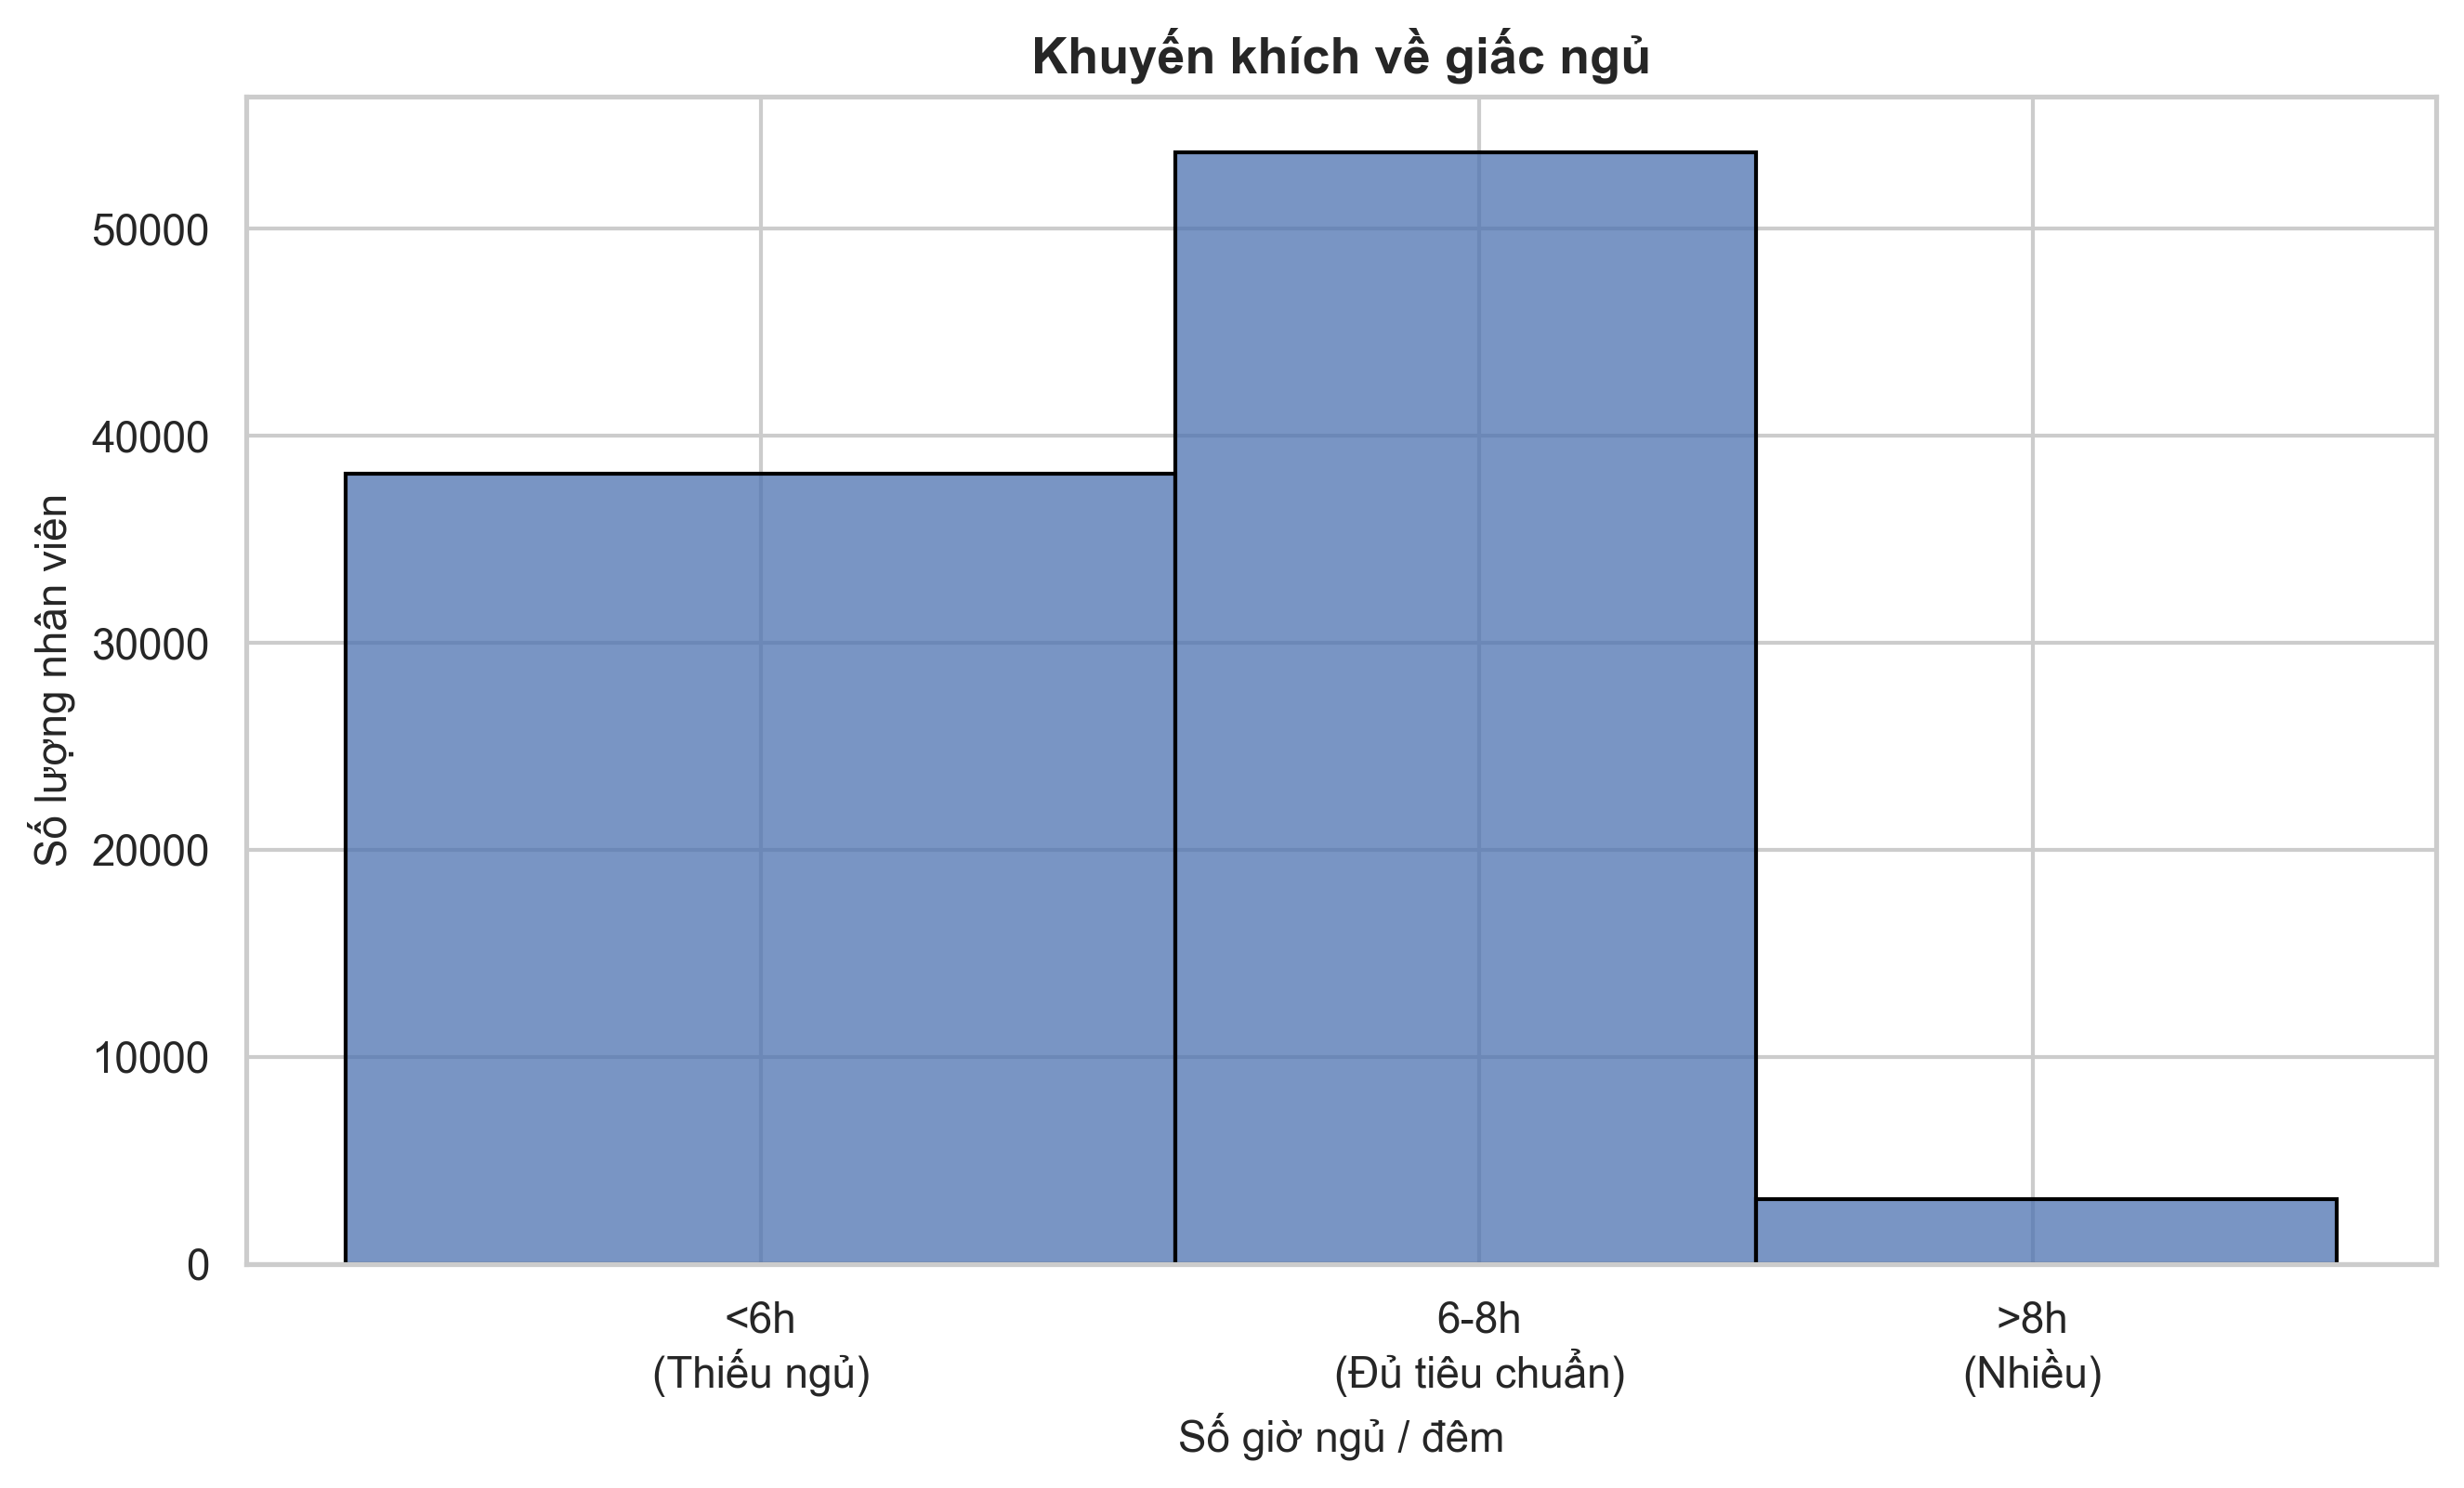

In [48]:
# EDA 5.9: Khuyến nghị sức khỏe (về giấc ngủ)
sleep_bins = [2.9, 5.9, 8.0, 10.1]
plt.figure(figsize=(9, 5.5), dpi=300)
sns.histplot(data=data, x="sleep_hours_per_night", bins=sleep_bins, edgecolor="black")
plt.title("Khuyến khích về giấc ngủ", fontweight="bold", fontsize=13)
plt.xlabel("Số giờ ngủ / đêm", fontsize=11)
plt.ylabel("Số lượng nhân viên", fontsize=11)
plt.xticks([4.4, 7.0, 9.0], ["<6h\n(Thiếu ngủ)", "6-8h\n(Đủ tiêu chuẩn)", ">8h\n(Nhiều)"])
plt.tight_layout()
plt.show()

Bảng tổng hợp Outlier theo IQR


,Tên cột,Số lượng Outlier,Tỷ lệ % Outlier,Giá trị Min,Giá trị Max,Ngưỡng dưới (Lower Bound),Ngưỡng trên (Upper Bound)
0,sleep_hours_per_night,606,0.64%,3.00,10.00,3.30,8.90
1,deadline_pressure_score,506,0.53%,1.00,10.00,1.60,11.20
2,salary_usd,409,0.43%,40000.00,267961.00,-48649.62,203915.38
3,work_hours_per_week,332,0.35%,35.00,72.00,33.50,61.50
4,gad7_score,123,0.13%,0.00,21.00,-7.00,17.00
5,phq9_score,64,0.07%,0.00,27.00,-10.00,22.00


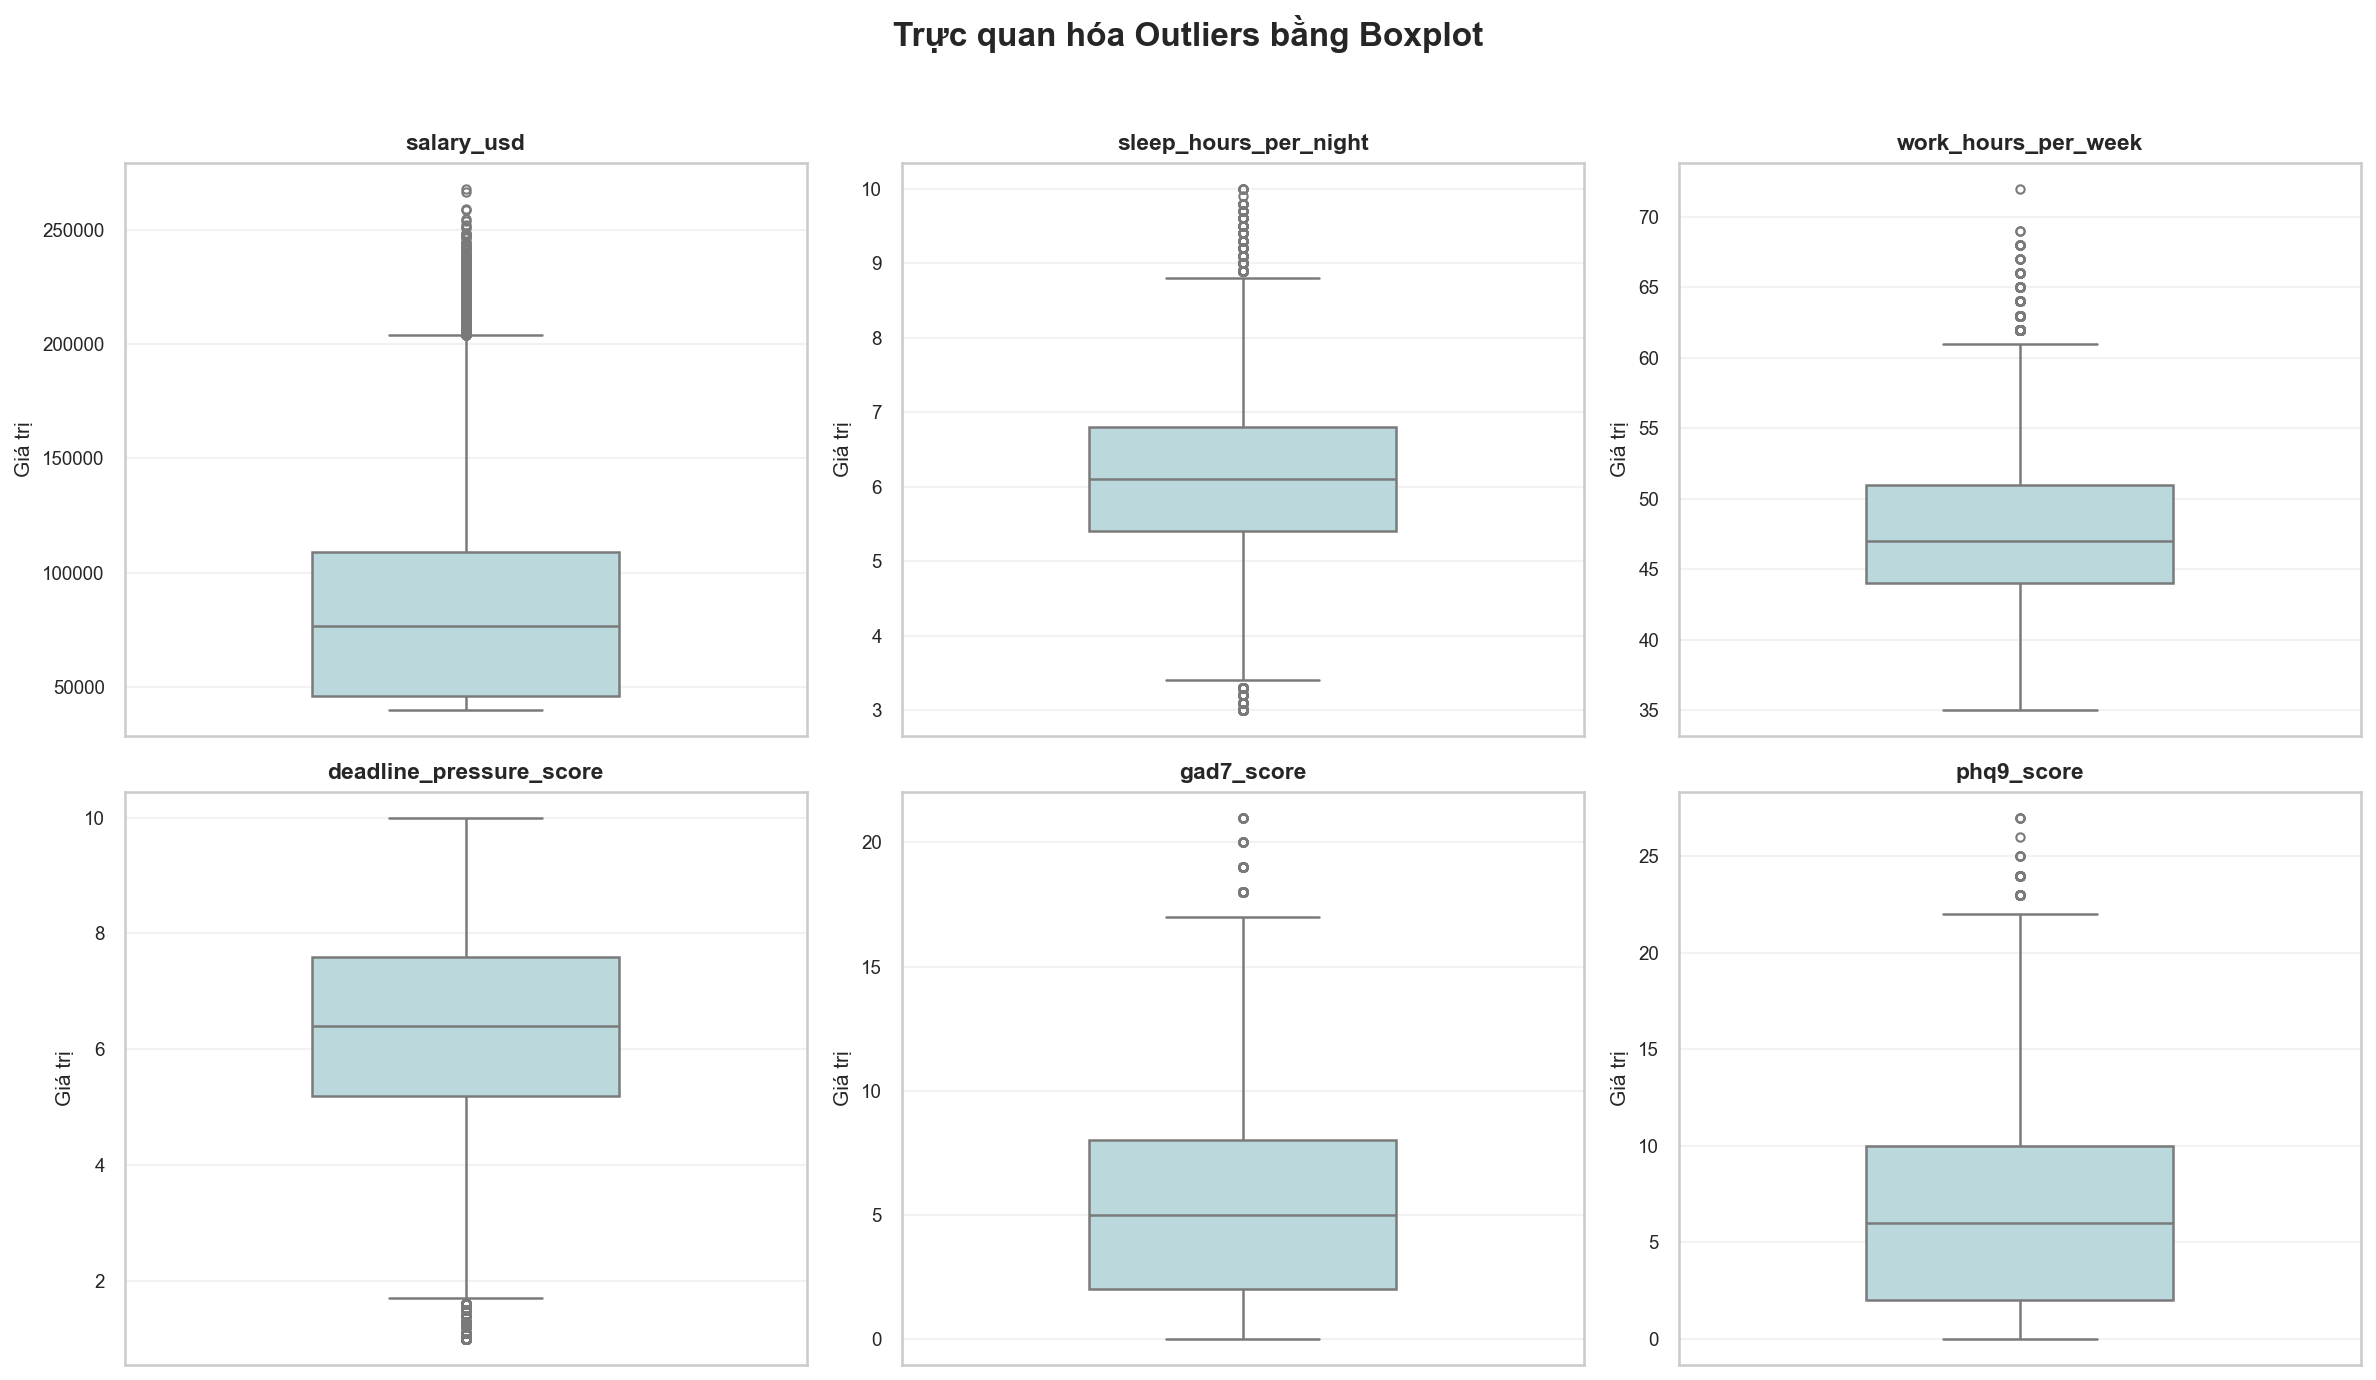

In [57]:
# EDA 6: Phân tích Outlier bằng IQR 
selected_columns = [
    "salary_usd",
    "sleep_hours_per_night",
    "work_hours_per_week",
    "deadline_pressure_score",
    "gad7_score",
    "phq9_score",
]
outlier_rows = []

for column in selected_columns:
    series = data[column].dropna()
    first_quartile = series.quantile(0.25)
    third_quartile = series.quantile(0.75)
    iqr = third_quartile - first_quartile
    lower_bound = first_quartile - 1.5 * iqr
    upper_bound = third_quartile + 1.5 * iqr
    outlier_count = ((series < lower_bound) | (series > upper_bound)).sum()
    valid_count = series.size

    outlier_rows.append({
        "Tên cột": column,
        "Số lượng Outlier": int(outlier_count),
        "Tỷ lệ % Outlier": (outlier_count / valid_count * 100) if valid_count else 0,
        "Giá trị Min": series.min() if valid_count else np.nan,
        "Giá trị Max": series.max() if valid_count else np.nan,
        "Ngưỡng dưới (Lower Bound)": lower_bound if valid_count else np.nan,
        "Ngưỡng trên (Upper Bound)": upper_bound if valid_count else np.nan,
    })

outlier_report = (
    pd.DataFrame(outlier_rows)
    .sort_values("Số lượng Outlier", ascending=False)
    .reset_index(drop=True)
)

print("Bảng tổng hợp Outlier theo IQR")
display(outlier_report.style.format({
    "Tỷ lệ % Outlier": "{:.2f}%",
    "Giá trị Min": "{:.2f}",
    "Giá trị Max": "{:.2f}",
    "Ngưỡng dưới (Lower Bound)": "{:.2f}",
    "Ngưỡng trên (Upper Bound)": "{:.2f}",
}))

subplot_columns = 3
subplot_rows = 2
fig, axes = plt.subplots(
    subplot_rows,
    subplot_columns,
    figsize=(16, 9),
    squeeze=False,
)
axes = axes.ravel()

for index, column in enumerate(selected_columns):
    sns.boxplot(
        y=data[column],
        ax=axes[index],
        color="#b5dce3",
        width=0.45,
        fliersize=4,
        linewidth=1.2,
    )
    axes[index].set_title(column, fontsize=11, fontweight="bold")
    axes[index].set_xlabel("")
    axes[index].set_ylabel("Giá trị", fontsize=10)
    axes[index].tick_params(axis="y", labelsize=9)
    axes[index].grid(axis="y", alpha=0.25)

fig.suptitle(
    "Trực quan hóa Outliers bằng Boxplot",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()


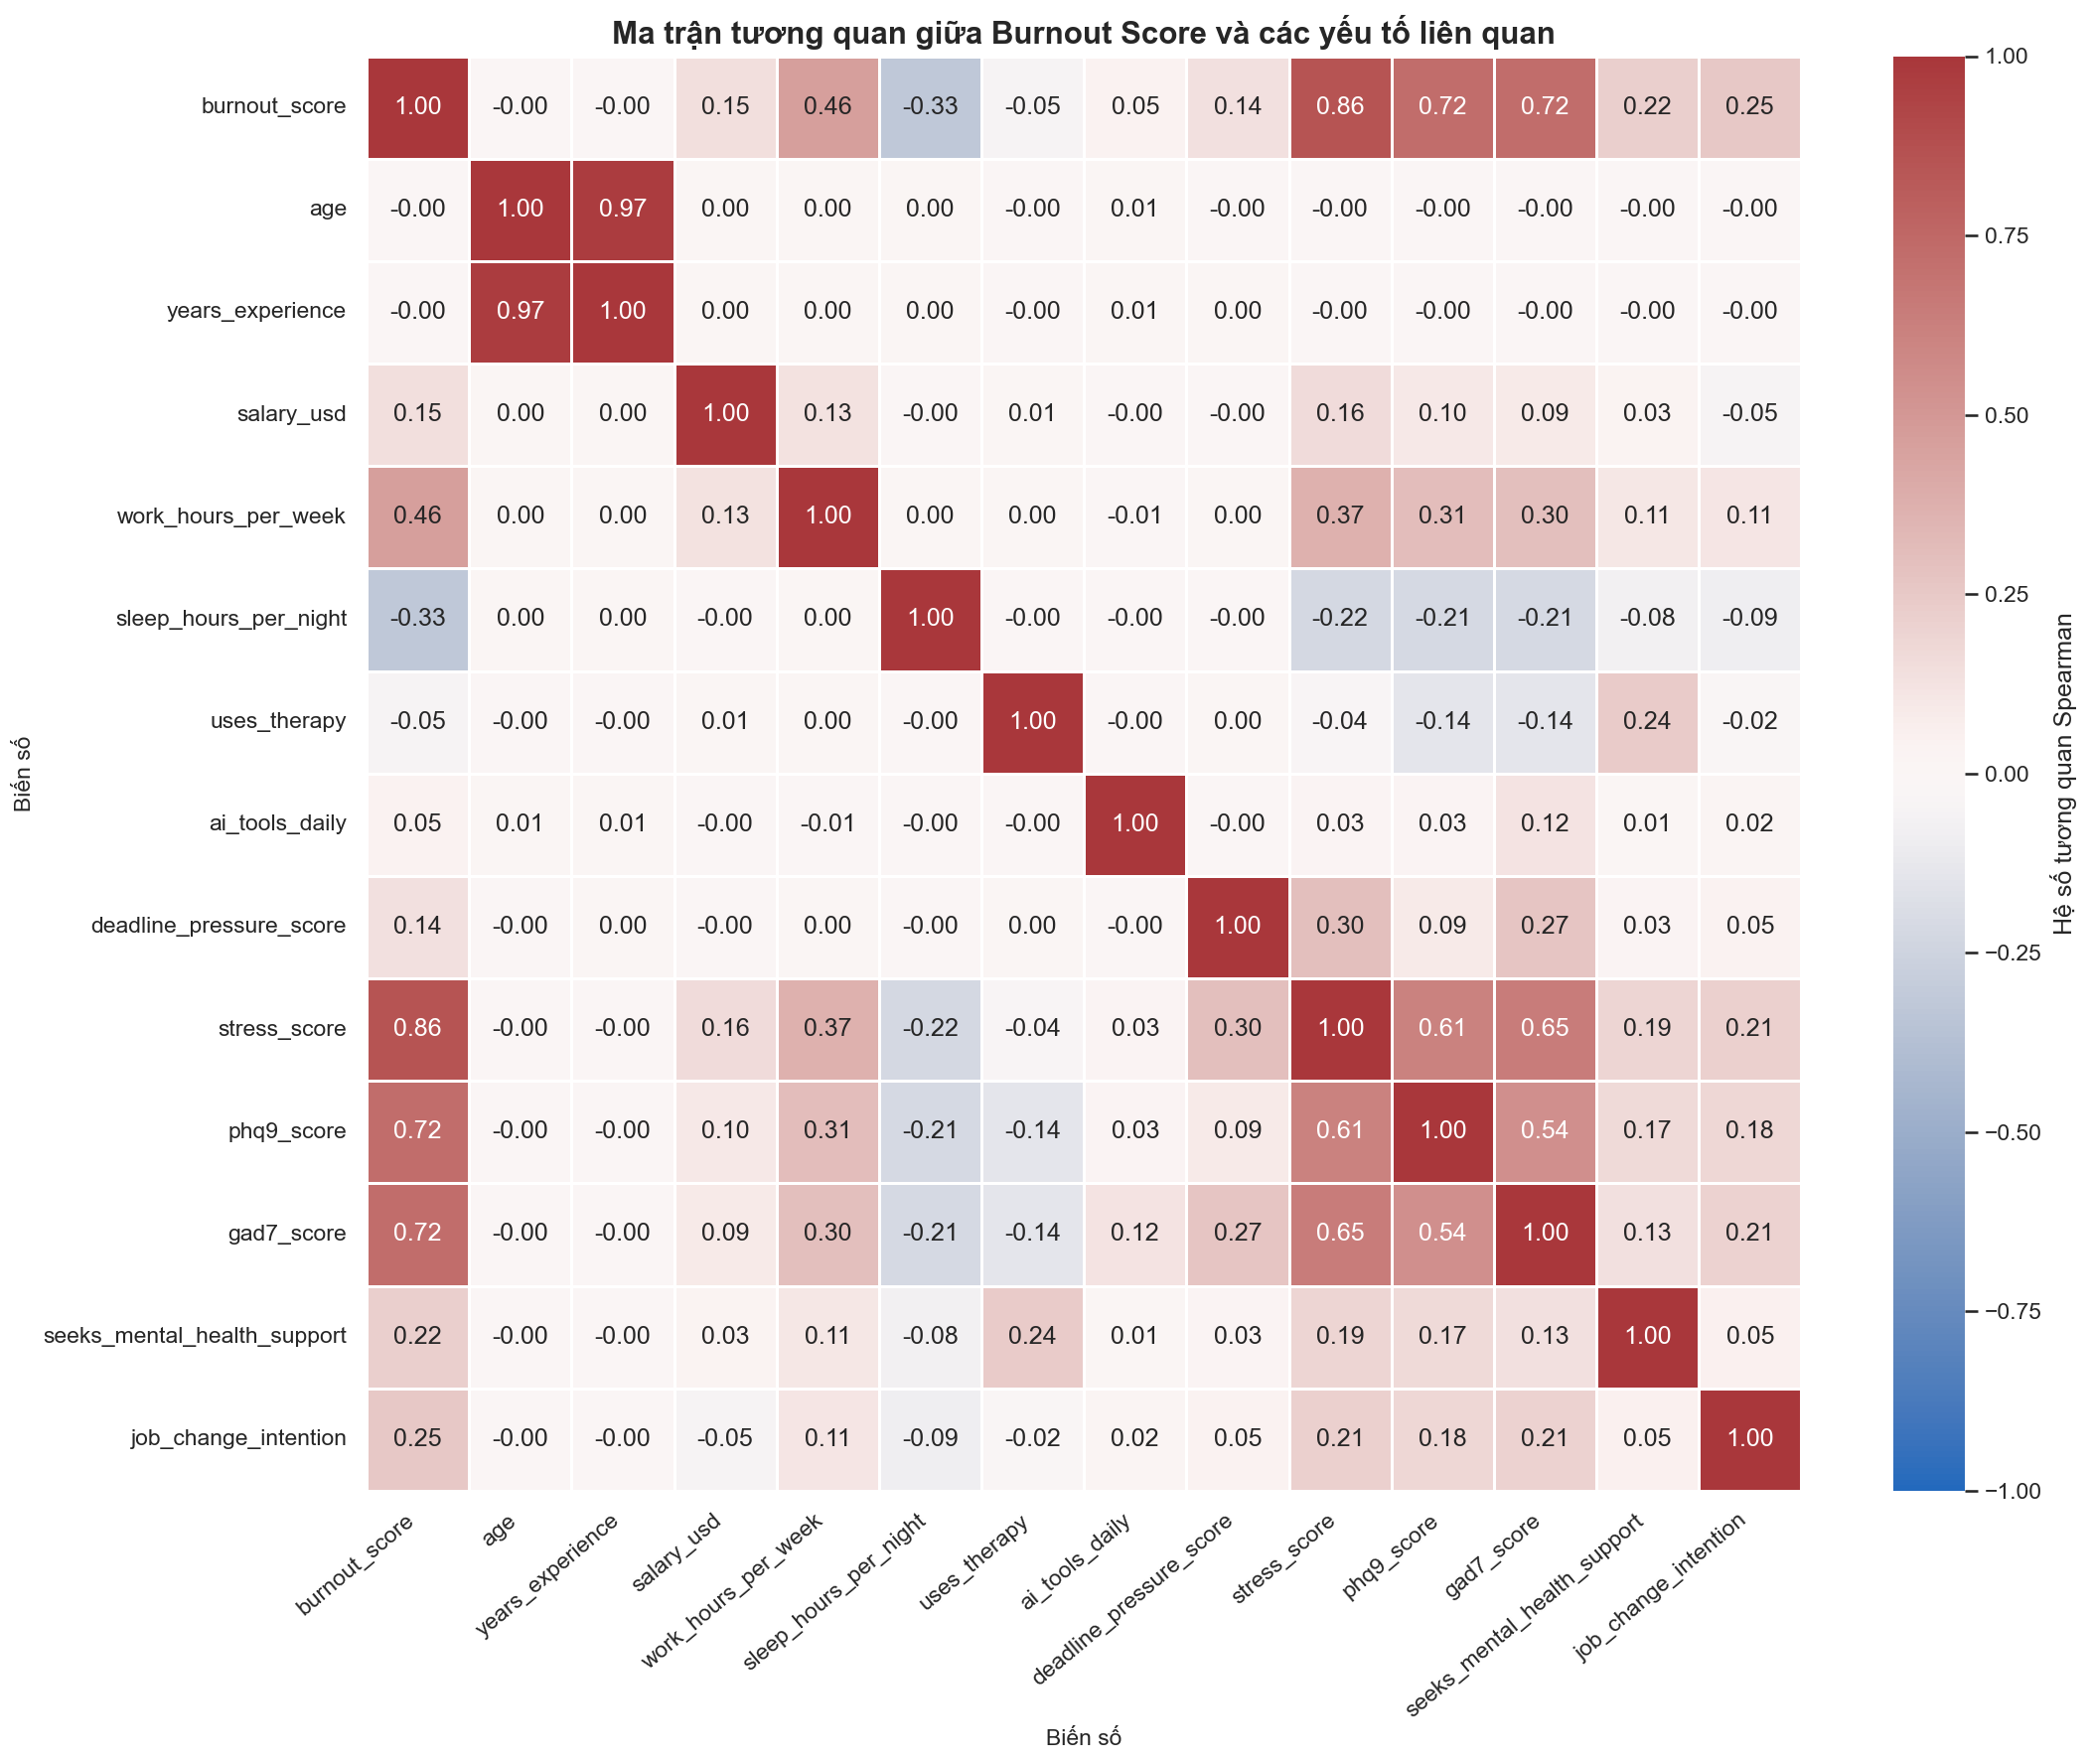

,|Tương quan Spearman với burnout_score|
stress_score,0.856128
gad7_score,0.723836
phq9_score,0.723816
work_hours_per_week,0.463994
sleep_hours_per_night,0.326906
job_change_intention,0.251295
seeks_mental_health_support,0.219667
salary_usd,0.148406
deadline_pressure_score,0.136754
uses_therapy,0.054024


In [ ]:
# EDA 7: Tương quan giữa burnout_score và các yếu tố liên quan
correlation_columns = [
    "burnout_score",
    "age",
    "years_experience",
    "salary_usd",
    "work_hours_per_week",
    "sleep_hours_per_night",
    "uses_therapy",
    "ai_tools_daily",
    "deadline_pressure_score",
    "stress_score",
    "phq9_score",
    "gad7_score",
    "seeks_mental_health_support",
    "job_change_intention",
]

correlation_matrix = data[correlation_columns].corr(method="spearman")

plt.figure(figsize=(15, 12))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Hệ số tương quan Spearman"},
)
plt.title(
    "Ma trận tương quan giữa Burnout Score và các yếu tố liên quan",
    fontweight="bold",
    fontsize=15,
)
plt.xlabel("Biến số", fontsize=11)
plt.ylabel("Biến số", fontsize=11)
plt.xticks(rotation=40, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

burnout_correlation = (
    correlation_matrix["burnout_score"]
    .drop("burnout_score")
    .abs()
    .sort_values(ascending=False)
    .to_frame("|Tương quan Spearman với burnout_score|")
)
burnout_correlation